In [1]:
import pandas as pd
import numpy as np

from scipy.stats import norm

from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>.output_result { max-width:100% !important; }</style>"))

pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

In [2]:
def format_plot(ax, size_axes=6, size_title=8):
    font_title = {"size": size_title, "weight": 400, "name": "monospace"}

    font_axes = {"size": size_axes, "weight": "bold", "name": "monospace"}

    ax.grid(True, linestyle=":", alpha=0.6)
    sns.despine(ax=ax, left=True)

    if ax.get_legend():
        ax.legend(bbox_to_anchor=(1.1, 1))

    ax.set_title(f"\n\n{ax.get_title()}\n", fontdict=font_title)
    ax.set_xlabel(f"\n{ax.get_xlabel()} ➞", fontdict=font_axes)
    ax.set_ylabel(f"{ax.get_ylabel()} ➞\n", fontdict=font_axes)

# performances
def print_performances(y_true, y_hat):
    
    ##### confusion matrix
    _, ax = plt.subplots(1,2,figsize=(8, 4))
    ax1, ax2 = ax[0], ax[1]
    
    # abs counts
    conf_matrix = pd.crosstab(index=y_true, columns=y_hat)
    
    sns.heatmap(data=conf_matrix,
                cmap="rocket",
                annot=True,
                cbar=False,
                fmt=".0f", 
                ax=ax1)
    
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    ax1.set_title('Confusion matrix (absolute)')
    
    # normalized by actual class
    conf_matrix_norm = pd.crosstab(index=y_true, columns=y_hat, normalize='index')
    sns.heatmap(data=conf_matrix_norm, cmap="rocket", annot=True, cbar=False, fmt=".2f", ax=ax2)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    ax2.set_title('Confusion matrix (normalized by class)')
    
    format_plot(ax1)
    format_plot(ax2)
    plt.show()
    
    # performances
    print(f'Accuracy: {round(accuracy_score(y_true, y_hat), 3)}')
    print(f'Recall: {round(recall_score(y_true, y_hat), 3)}')
    print(f'Precision: {round(precision_score(y_true, y_hat), 3)}')
    print(f'F1: {round(f1_score(y_true, y_hat), 3)}')
    print(f'ROC AUC: {round(roc_auc_score(y_true, y_hat), 3)}')

# Naive Bayes

In [3]:
def fitNB(data, class_att, alpha=1):
    model = {}
    
    # Računanje apriori verovatnoća
    apriori = data[class_att].value_counts()
    apriori = apriori/apriori.sum(axis=0)
    model['_apriori'] = apriori
    
    for attribute in data.drop(class_att, axis=1).columns:
        if data[attribute].dtype == 'object':  # za kategoričke
            # Kreiranje matrica kontigencije i dodavanje additive smoothing:
            mat_cont = pd.crosstab(data[attribute], data[class_att]) + alpha
            mat_cont = mat_cont / mat_cont.sum(axis=0)
            model[attribute] = mat_cont 
        else: # za numeričke
            # Računanje mean i std za svaku klasu
            class_mean_std = data.groupby(class_att)[attribute].agg(['mean', 'std'])
            model[attribute] = class_mean_std.T
            
    return model

def predictNB(model, new_instance):
    class_log_prob = {}
    class_prob = {}
    class_probabilities = {}
    
    # Računanje verovatnoća po svakoj klasi za nove instance
    for class_value in model['_apriori'].index:
        log_prob = 0
        
        # Računanje verovatnoća po svakom atributu za datu klasu
        for attribute in model.keys():
                        
            if attribute != '_apriori':
                # za nedostajuće vrednosti
                if new_instance[attribute] is np.nan:
                    continue
                
                if isinstance(new_instance[attribute], str): # za kategoričke
                    if new_instance[attribute] not in model[attribute].index:
                        continue
                    log_prob += np.log(model[attribute][class_value].loc[new_instance[attribute]])
                else: # za numeričke
                    mean, std = model[attribute][class_value].loc['mean'], model[attribute][class_value].loc['std']
                    log_prob += np.log(norm.pdf(x=new_instance[attribute], loc=mean, scale=std))
            else:
                log_prob += np.log(model['_apriori'][class_value])
        
        class_log_prob[class_value] = log_prob
        
    
    for class_value in class_log_prob.keys():
        class_prob[class_value] = np.exp(class_log_prob[class_value]-(max((class_log_prob.values()))))
    for class_value in class_prob.keys():
        class_probabilities[class_value] = class_prob[class_value]/(sum(class_prob.values()))
    
        
    # Predvidjanje:
    prediction = max(class_probabilities, key=class_probabilities.get)
    
    return prediction, class_probabilities

# Fair Naive Bayes

In [4]:
def fit(data, class_att, positive_class, sensitive_att, p, alpha=1):
    model = {}
    
    # Računanje apriori verovatnoća
    apriori = data[class_att].value_counts()
    apriori = apriori/apriori.sum(axis=0)
    model['_apriori'] = apriori
    
    for attribute in data.drop(class_att, axis=1).columns:
        if attribute in sensitive_att: #za osetljivi atribut
            a = min(pd.crosstab(data[attribute], data[class_att])[positive_class])
            b = max(pd.crosstab(data[attribute], data[class_att])[positive_class])
            c = a/b
            if p < c:
                print(f'Atribut {attribute} je već više balansiran od traženih {p}, zadržaće se postojeći balans koji iznosi {c}')
                continue
            elif p > 0.99:
                print('Nije moguće toliko izbalansirati')
                break
            else:
                alpha_s = (p*b-a)/(1-p)
                mat_cont = pd.crosstab(data[attribute], data[class_att]) + alpha_s
                mat_cont = mat_cont / mat_cont.sum(axis=0)
                model[attribute] = mat_cont
            
        else:
            
            if data[attribute].dtype == 'object':  # za kategoričke
                # Kreiranje matrica kontigencije i dodavanje additive smoothing:
                mat_cont = pd.crosstab(data[attribute], data[class_att]) + alpha
                mat_cont = mat_cont / mat_cont.sum(axis=0)
                model[attribute] = mat_cont
            else: # za numeričke
                # Računanje mean i std za svaku klasu
                class_mean_std = data.groupby(class_att)[attribute].agg(['mean', 'std'])
                model[attribute] = class_mean_std.T
            
    return model

In [5]:
def predict(model, new_instance, target_class=1, other_class=0, threshold=0.5):
    class_log_prob = {}
    class_prob = {}
    class_probabilities = {}
    
    # Računanje verovatnoća po svakoj klasi za nove instance
    for class_value in model['_apriori'].index:
        log_prob = 0
        
        # Računanje verovatnoća po svakom atributu za datu klasu
        for attribute in model.keys():
                        
            if attribute != '_apriori':
                # za nedostajuće vrednosti
                if new_instance[attribute] is np.nan:
                    continue
                
                if isinstance(new_instance[attribute], str): # za kategoričke
                    if new_instance[attribute] not in model[attribute].index:
                        continue
                    log_prob += np.log(model[attribute][class_value].loc[new_instance[attribute]])
                else: # za numeričke
                    mean, std = model[attribute][class_value].loc['mean'], model[attribute][class_value].loc['std']
                    log_prob += np.log(norm.pdf(x=new_instance[attribute], loc=mean, scale=std))
            else:
                log_prob += np.log(model['_apriori'][class_value])
        
        class_log_prob[class_value] = log_prob
        
    
    for class_value in class_log_prob.keys():
        class_prob[class_value] = np.exp(class_log_prob[class_value]-(max((class_log_prob.values()))))
    for class_value in class_prob.keys():
        class_probabilities[class_value] = class_prob[class_value]/(sum(class_prob.values()))
    
        
    # Predvidjanje:
    if class_probabilities[target_class] >= threshold:
        prediction = target_class
    else: 
        prediction = other_class
    
    return prediction, class_probabilities

In [6]:
#Mere za diskriminaciju

def di (X_test_p, prediction, sens_att, priv_class, disc_class):
    PPD = (X_test_p[prediction][(X_test_p[sens_att]==disc_class) & (X_test_p[prediction]==True)].count()) 
    D = (X_test_p[prediction][(X_test_p[sens_att] == disc_class)]).count()
    PPP = (X_test_p[prediction][(X_test_p[sens_att] == priv_class) & (X_test_p[prediction]==True)].count())
    P = (X_test_p[prediction][(X_test_p[sens_att] == priv_class)]).count()
    DI = round((PPD/D)/(PPP/P), 3)
    return DI

def eq (X_test, X_test_p, actual, prediction, sens_att, priv_class, disc_class):
    TPD = (X_test_p[prediction][(X_test_p[sens_att] == disc_class) & (X_test_p[prediction]==True) & (X_test[actual]==True)].count()) 
    APD = (X_test[actual][(X_test[sens_att] == disc_class) & (X_test[actual]==True)].count())
    TPP = (X_test_p[prediction][(X_test_p[sens_att] == priv_class) & (X_test_p[prediction]==True) & (X_test[actual]==True)].count()) 
    APP = (X_test[actual][(X_test[sens_att] == priv_class) & (X_test[actual]==True)].count()) 
    EQ = round((TPD/APD)/(TPP/APP), 3)
    return EQ

# Compas dataset

#### Priprema podataka

In [7]:
data = pd.read_csv('data/compas.csv') 
data

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,0,7,0,0,0,-1.0,2013-11-22 05:18:27,2013-11-24 02:59:20,13016249CF10A,2013-11-22,NaN,1.0,F,Deliver Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,7,Medium,2013-11-23,Risk of Violence,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,0,3,0,0,0,-1.0,2014-01-31 07:13:54,2014-02-02 04:03:52,14001422CF10A,2014-01-31,NaN,1.0,F,Leaving the Scene of Accident,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,3,Low,2014-02-01,Risk of Violence,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,0,1,0,0,0,-1.0,2014-01-13 05:48:01,2014-01-14 07:49:46,14000581CF10A,2014-01-13,NaN,1.0,F,Aggravated Battery / Pregnant,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-01-14,Risk of Violence,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,0,2,0,0,3,-1.0,2014-03-08 08:06:02,2014-03-09 12:18:04,140033

In [8]:
data = data.drop(['id', 'name', 'first', 'last', 'compas_screening_date', 'dob', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 
                  'c_arrest_date', 'r_case_number', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'c_charge_desc', 'r_jail_in', 
                  'violent_recid', 'vr_case_number', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'screening_date', 
                  'v_type_of_assessment', 'v_screening_date', 'in_custody', 'out_custody', 'r_jail_out', 'start', 'end', 'two_year_recid', 
                  'r_charge_degree', 'vr_charge_degree', 'event', 'is_violent_recid'], axis=1)

In [9]:
data

,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,c_charge_degree,is_recid,decile_score.1,score_text,v_decile_score,v_score_text,priors_count.1
0,Male,69,Greater than 45,Other,0,1,0,0,0,-1.0,1.0,F,0,1,Low,1,Low,0
1,Male,34,25 - 45,African-American,0,3,0,0,0,-1.0,1.0,F,1,3,Low,1,Low,0
2,Male,24,Less than 25,African-American,0,4,0,1,4,-1.0,1.0,F,1,4,Low,3,Low,4
3,Male,23,Less than 25,African-American,0,8,1,0,1,NaN,1.0,F,0,8,High,6,Medium,1
4,Male,43,25 - 45,Other,0,1,0,0,2,NaN,76.0,F,0,1,Low,1,Low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,Male,23,Less than 25,African-American,0,7,0,0,0,-1.0,1.0,F,0,7,Medium,5,Medium,0
7210,Male,23,Less than 25,African-American,0,3,0,0,0,-1.0,1.0,F,0,3,Low,5,Medium,0
7211,Male,57,Greater than 45,Other,0,1,0,0,0,-1.0,1.0,F,0,1,Low,1,Low,0
7212,Female,33,25 - 45,African-American,0,2,0,0,3,-1.0,1.0,M,0,2,Low,2,Low,3


In [10]:
data['race'].value_counts()

African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: race, dtype: int64

In [11]:
data = data.drop(data[(data['race']=='Hispanic') | (data['race']=='Other') | (data['race']=='Asian') | (data['race']== 'Native American')].index)

In [12]:
data['race'].value_counts()

African-American    3696
Caucasian           2454
Name: race, dtype: int64

In [13]:
data.describe()

,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,decile_score.1,v_decile_score,priors_count.1
count,6150.000000,6150.000000,6150.000000,6150.000000,6150.000000,6150.000000,5915.000000,6136.000000,6150.000000,6150.000000,6150.000000,6150.000000
mean,34.730244,0.070732,4.716911,0.098699,0.117886,3.699837,3.055283,58.021023,0.497724,4.716911,3.815610,3.699837
std,11.907074,0.436621,2.854644,0.504829,0.517938,5.028782,73.438055,329.258891,0.500035,2.854644,2.529092,5.028782
min,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-414.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,2.000000,2.000000,0.000000
50%,31.000000,0.000000,4.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,4.000000,3.000000,2.000000
75%,42.000000,0.000000,7.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,7.000000,6.000000,5.000000
max,83.000000,10.000000,10.000000,13.000000,17.000000,38.000000,1057.000000,9485.000000,1.000000,10.000000,10.000000,38.000000


In [14]:
data['is_recid'].value_counts()

0    3089
1    3061
Name: is_recid, dtype: int64

In [15]:
mat_cont = pd.crosstab(data['race'], data['is_recid'])
mat_cont

is_recid,0,1
race,,
African-American,1660,2036
Caucasian,1429,1025


In [16]:
mat_cont = pd.crosstab(data['sex'], data['is_recid'])
mat_cont

is_recid,0,1
sex,,
Female,745,474
Male,2344,2587


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6150 entries, 1 to 7212
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sex                      6150 non-null   object 
 1   age                      6150 non-null   int64  
 2   age_cat                  6150 non-null   object 
 3   race                     6150 non-null   object 
 4   juv_fel_count            6150 non-null   int64  
 5   decile_score             6150 non-null   int64  
 6   juv_misd_count           6150 non-null   int64  
 7   juv_other_count          6150 non-null   int64  
 8   priors_count             6150 non-null   int64  
 9   days_b_screening_arrest  5915 non-null   float64
 10  c_days_from_compas       6136 non-null   float64
 11  c_charge_degree          6150 non-null   object 
 12  is_recid                 6150 non-null   int64  
 13  decile_score.1           6150 non-null   int64  
 14  score_text              

### Primena osnovnog algoritma Naive Bayes

In [18]:
X_trainO, X_testO = train_test_split(data, test_size=0.3, random_state=297)
X_trainO, X_testO = X_trainO.reset_index(drop=True), X_testO.reset_index(drop=True)

X_test_pO = X_testO.drop('is_recid', axis=1)

modelO = fitNB(data=X_trainO, class_att='is_recid', alpha=0)

In [19]:
modelO

{'_apriori': 0    0.503833
 1    0.496167
 Name: is_recid, dtype: float64,
 'sex': is_recid         0         1
 sex                         
 Female    0.241125  0.158708
 Male      0.758875  0.841292,
 'age': is_recid          0          1
 mean      37.078838  32.374532
 std       12.642500  10.738457,
 'age_cat': is_recid                0         1
 age_cat                            
 25 - 45          0.555556  0.580993
 Greater than 45  0.276625  0.154963
 Less than 25     0.167819  0.264045,
 'race': is_recid                 0        1
 race                               
 African-American  0.541263  0.65824
 Caucasian         0.458737  0.34176,
 'juv_fel_count': is_recid         0         1
 mean      0.030890  0.108614
 std       0.243864  0.558855,
 'decile_score': is_recid         0         1
 mean      3.741817  5.713483
 std       2.579137  2.749039,
 'juv_misd_count': is_recid         0         1
 mean      0.043338  0.140918
 std       0.317048  0.540874,
 'juv_other_cou

In [20]:
X_test_pO

,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,c_charge_degree,decile_score.1,score_text,v_decile_score,v_score_text,priors_count.1
0,Male,50,Greater than 45,Caucasian,0,1,0,0,1,-1.0,1.0,M,1,Low,1,Low,1
1,Male,26,25 - 45,African-American,0,8,0,0,0,-1.0,1.0,F,8,High,4,Low,0
2,Male,24,Less than 25,African-American,0,2,0,0,1,-1.0,1.0,F,2,Low,3,Low,1
3,Male,33,25 - 45,Caucasian,0,9,0,0,10,0.0,0.0,F,9,High,8,High,10
4,Male,25,25 - 45,African-American,0,5,0,0,0,0.0,1.0,M,5,Medium,5,Medium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1840,Male,35,25 - 45,African-American,0,1,0,0,0,-1.0,1.0,F,1,Low,1,Low,0
1841,Male,30,25 - 45,African-American,0,7,0,0,11,0.0,0.0,F,7,Medium,6,Medium,11
1842,Male,23,Less than 25,Caucasian,0,8,0,0,3,-1.0,1.0,M,8,High,5,Medium,3
1843,Female,51,Greater than 45,African-American,0,1,0,0,4,-60.0,60.0,F,1,Low,1,Low,4


In [21]:
time_started = datetime.now()

for i in range(len(X_test_pO)):
    print(f'Iteration: {i}')
    prediction, confidence = predictNB(model = modelO , new_instance = X_test_pO.loc[i])
    
    X_test_pO.loc[i,'prediction'] = prediction
    
    for klasa in confidence:
        X_test_pO.loc[i,'class='+str(klasa)] = confidence[klasa]
        
time_finished = datetime.now()
run_last = (time_finished - time_started).seconds / 60
print(f'-----------------------------\nPrediction last: {run_last} mins.')

Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
It

Iteration: 604
Iteration: 605
Iteration: 606
Iteration: 607
Iteration: 608
Iteration: 609
Iteration: 610
Iteration: 611
Iteration: 612
Iteration: 613
Iteration: 614
Iteration: 615
Iteration: 616
Iteration: 617
Iteration: 618
Iteration: 619
Iteration: 620
Iteration: 621
Iteration: 622
Iteration: 623
Iteration: 624
Iteration: 625
Iteration: 626
Iteration: 627
Iteration: 628
Iteration: 629
Iteration: 630
Iteration: 631
Iteration: 632
Iteration: 633
Iteration: 634
Iteration: 635
Iteration: 636
Iteration: 637
Iteration: 638
Iteration: 639
Iteration: 640
Iteration: 641
Iteration: 642
Iteration: 643
Iteration: 644
Iteration: 645
Iteration: 646
Iteration: 647
Iteration: 648
Iteration: 649
Iteration: 650
Iteration: 651
Iteration: 652
Iteration: 653
Iteration: 654
Iteration: 655
Iteration: 656
Iteration: 657
Iteration: 658
Iteration: 659
Iteration: 660
Iteration: 661
Iteration: 662
Iteration: 663
Iteration: 664
Iteration: 665
Iteration: 666
Iteration: 667
Iteration: 668
Iteration: 669
Iteration:

Iteration: 1153
Iteration: 1154
Iteration: 1155
Iteration: 1156
Iteration: 1157
Iteration: 1158
Iteration: 1159
Iteration: 1160
Iteration: 1161
Iteration: 1162
Iteration: 1163
Iteration: 1164
Iteration: 1165
Iteration: 1166
Iteration: 1167
Iteration: 1168
Iteration: 1169
Iteration: 1170
Iteration: 1171
Iteration: 1172
Iteration: 1173
Iteration: 1174
Iteration: 1175
Iteration: 1176
Iteration: 1177
Iteration: 1178
Iteration: 1179
Iteration: 1180
Iteration: 1181
Iteration: 1182
Iteration: 1183
Iteration: 1184
Iteration: 1185
Iteration: 1186
Iteration: 1187
Iteration: 1188
Iteration: 1189
Iteration: 1190
Iteration: 1191
Iteration: 1192
Iteration: 1193
Iteration: 1194
Iteration: 1195
Iteration: 1196
Iteration: 1197
Iteration: 1198
Iteration: 1199
Iteration: 1200
Iteration: 1201
Iteration: 1202
Iteration: 1203
Iteration: 1204
Iteration: 1205
Iteration: 1206
Iteration: 1207
Iteration: 1208
Iteration: 1209
Iteration: 1210
Iteration: 1211
Iteration: 1212
Iteration: 1213
Iteration: 1214
Iteratio

Iteration: 1679
Iteration: 1680
Iteration: 1681
Iteration: 1682
Iteration: 1683
Iteration: 1684
Iteration: 1685
Iteration: 1686
Iteration: 1687
Iteration: 1688
Iteration: 1689
Iteration: 1690
Iteration: 1691
Iteration: 1692
Iteration: 1693
Iteration: 1694
Iteration: 1695
Iteration: 1696
Iteration: 1697
Iteration: 1698
Iteration: 1699
Iteration: 1700
Iteration: 1701
Iteration: 1702
Iteration: 1703
Iteration: 1704
Iteration: 1705
Iteration: 1706
Iteration: 1707
Iteration: 1708
Iteration: 1709
Iteration: 1710
Iteration: 1711
Iteration: 1712
Iteration: 1713
Iteration: 1714
Iteration: 1715
Iteration: 1716
Iteration: 1717
Iteration: 1718
Iteration: 1719
Iteration: 1720
Iteration: 1721
Iteration: 1722
Iteration: 1723
Iteration: 1724
Iteration: 1725
Iteration: 1726
Iteration: 1727
Iteration: 1728
Iteration: 1729
Iteration: 1730
Iteration: 1731
Iteration: 1732
Iteration: 1733
Iteration: 1734
Iteration: 1735
Iteration: 1736
Iteration: 1737
Iteration: 1738
Iteration: 1739
Iteration: 1740
Iteratio

*************************************** African-American ************************************ 


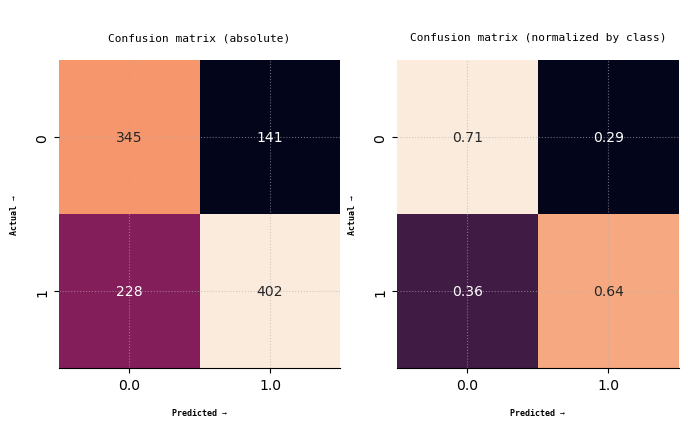

Accuracy: 0.669
Recall: 0.638
Precision: 0.74
F1: 0.685
ROC AUC: 0.674
**************************************** Caucasian ************************************* 


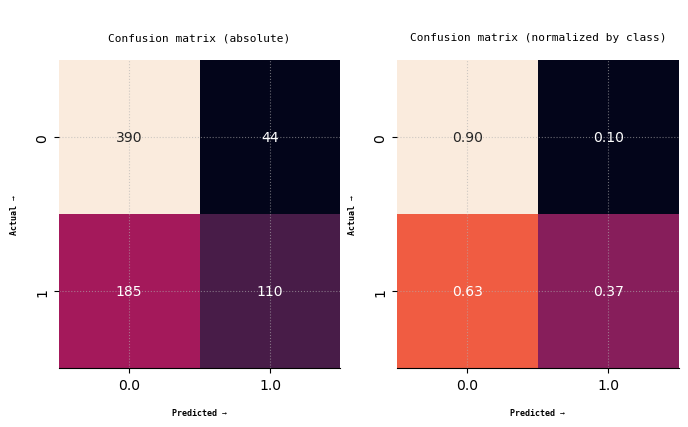

Accuracy: 0.686
Recall: 0.373
Precision: 0.714
F1: 0.49
ROC AUC: 0.636
**************************************** All ************************************* 


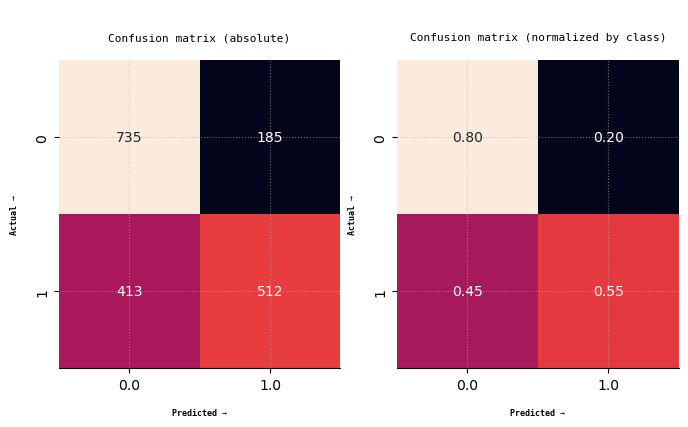

Accuracy: 0.676
Recall: 0.554
Precision: 0.735
F1: 0.631
ROC AUC: 0.676
Disparate impact: 0.434
Equal opportunity: 0.584


In [22]:
# African-American
print('*************************************** African-American ************************************ ')
print_performances(y_true=X_testO.loc[X_testO['race'] == 'African-American', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_pO.loc[X_test_pO['race'] == 'African-American', 'prediction'].reset_index(drop=True))

# Caucasian
print('**************************************** Caucasian ************************************* ')
print_performances(y_true=X_testO.loc[X_testO['race'] == 'Caucasian', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_pO.loc[X_test_pO['race'] == 'Caucasian', 'prediction'].reset_index(drop=True))

# All
print('**************************************** All ************************************* ')
print_performances(y_true=X_testO['is_recid'], y_hat=X_test_pO['prediction'])


#Disparate impact:
PPAA = (X_test_pO['prediction'][(X_test_pO['race'] == 'African-American') & (X_test_pO['prediction']==True)].count())
AA = (X_test_pO['prediction'][(X_test_pO['race'] == 'African-American')]).count()
PPC = (X_test_pO['prediction'][(X_test_pO['race'] == 'Caucasian') & (X_test_pO['prediction']==True)].count())
C = (X_test_pO['prediction'][(X_test_pO['race'] == 'Caucasian')]).count()
DI = round((PPC/C)/(PPAA/AA), 3)

#Equal opportunity:
TPAA = (X_test_pO['prediction'][(X_test_pO['race'] == 'African-American') & (X_test_pO['prediction']==True) & (X_testO['is_recid']==True)].count())
APAA = (X_testO['is_recid'][(X_testO['race'] == 'African-American') & (X_testO['is_recid']==True)].count())
TPC = (X_test_pO['prediction'][(X_test_pO['race'] == 'Caucasian') & (X_test_pO['prediction']==True) & (X_testO['is_recid']==True)].count())
APC = (X_testO['is_recid'][(X_testO['race'] == 'Caucasian') & (X_testO['is_recid']==True)].count())
EQ = round((TPC/APC)/(TPAA/APAA), 3)

print(f'Disparate impact: {DI}')
print (f'Equal opportunity: {EQ}')

### Primena modifikovane verzije algoritma Naive Bayes

#### Za p=0.8

In [23]:
X_train1, X_test1 = train_test_split(data, test_size=0.3, random_state=297)
X_train1, X_test1 = X_train1.reset_index(drop=True), X_test1.reset_index(drop=True)

X_test_p1 = X_test1.drop('is_recid', axis=1)

In [24]:
model1 = fit(data=X_train1, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex'], p=0.8)

In [25]:
model1

{'_apriori': 0    0.503833
 1    0.496167
 Name: is_recid, dtype: float64,
 'sex': is_recid         0         1
 sex                         
 Female    0.457317  0.444444
 Male      0.542683  0.555556,
 'age': is_recid          0          1
 mean      37.078838  32.374532
 std       12.642500  10.738457,
 'age_cat': is_recid                0         1
 age_cat                            
 25 - 45          0.552524  0.577562
 Greater than 45  0.277399  0.157433
 Less than 25     0.170077  0.265005,
 'race': is_recid                 0         1
 race                                
 African-American  0.514631  0.555556
 Caucasian         0.485369  0.444444,
 'juv_fel_count': is_recid         0         1
 mean      0.030890  0.108614
 std       0.243864  0.558855,
 'decile_score': is_recid         0         1
 mean      3.741817  5.713483
 std       2.579137  2.749039,
 'juv_misd_count': is_recid         0         1
 mean      0.043338  0.140918
 std       0.317048  0.540874,
 'juv_other

In [26]:
time_started = datetime.now()

for i in range(len(X_test_p1)):
    print(f'Iteration: {i}')
    prediction1, confidence1 = predict(model=model1, new_instance=X_test_p1.loc[i])
    
    X_test_p1.loc[i,'prediction'] = prediction1
    
    for klasa in confidence1:
        X_test_p1.loc[i,'class='+str(klasa)] = confidence1[klasa]
        
time_finished = datetime.now()
run_last = (time_finished - time_started).seconds / 60
print(f'-----------------------------\nPrediction last: {run_last} mins.')

Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
It

Iteration: 594
Iteration: 595
Iteration: 596
Iteration: 597
Iteration: 598
Iteration: 599
Iteration: 600
Iteration: 601
Iteration: 602
Iteration: 603
Iteration: 604
Iteration: 605
Iteration: 606
Iteration: 607
Iteration: 608
Iteration: 609
Iteration: 610
Iteration: 611
Iteration: 612
Iteration: 613
Iteration: 614
Iteration: 615
Iteration: 616
Iteration: 617
Iteration: 618
Iteration: 619
Iteration: 620
Iteration: 621
Iteration: 622
Iteration: 623
Iteration: 624
Iteration: 625
Iteration: 626
Iteration: 627
Iteration: 628
Iteration: 629
Iteration: 630
Iteration: 631
Iteration: 632
Iteration: 633
Iteration: 634
Iteration: 635
Iteration: 636
Iteration: 637
Iteration: 638
Iteration: 639
Iteration: 640
Iteration: 641
Iteration: 642
Iteration: 643
Iteration: 644
Iteration: 645
Iteration: 646
Iteration: 647
Iteration: 648
Iteration: 649
Iteration: 650
Iteration: 651
Iteration: 652
Iteration: 653
Iteration: 654
Iteration: 655
Iteration: 656
Iteration: 657
Iteration: 658
Iteration: 659
Iteration:

Iteration: 1142
Iteration: 1143
Iteration: 1144
Iteration: 1145
Iteration: 1146
Iteration: 1147
Iteration: 1148
Iteration: 1149
Iteration: 1150
Iteration: 1151
Iteration: 1152
Iteration: 1153
Iteration: 1154
Iteration: 1155
Iteration: 1156
Iteration: 1157
Iteration: 1158
Iteration: 1159
Iteration: 1160
Iteration: 1161
Iteration: 1162
Iteration: 1163
Iteration: 1164
Iteration: 1165
Iteration: 1166
Iteration: 1167
Iteration: 1168
Iteration: 1169
Iteration: 1170
Iteration: 1171
Iteration: 1172
Iteration: 1173
Iteration: 1174
Iteration: 1175
Iteration: 1176
Iteration: 1177
Iteration: 1178
Iteration: 1179
Iteration: 1180
Iteration: 1181
Iteration: 1182
Iteration: 1183
Iteration: 1184
Iteration: 1185
Iteration: 1186
Iteration: 1187
Iteration: 1188
Iteration: 1189
Iteration: 1190
Iteration: 1191
Iteration: 1192
Iteration: 1193
Iteration: 1194
Iteration: 1195
Iteration: 1196
Iteration: 1197
Iteration: 1198
Iteration: 1199
Iteration: 1200
Iteration: 1201
Iteration: 1202
Iteration: 1203
Iteratio

Iteration: 1675
Iteration: 1676
Iteration: 1677
Iteration: 1678
Iteration: 1679
Iteration: 1680
Iteration: 1681
Iteration: 1682
Iteration: 1683
Iteration: 1684
Iteration: 1685
Iteration: 1686
Iteration: 1687
Iteration: 1688
Iteration: 1689
Iteration: 1690
Iteration: 1691
Iteration: 1692
Iteration: 1693
Iteration: 1694
Iteration: 1695
Iteration: 1696
Iteration: 1697
Iteration: 1698
Iteration: 1699
Iteration: 1700
Iteration: 1701
Iteration: 1702
Iteration: 1703
Iteration: 1704
Iteration: 1705
Iteration: 1706
Iteration: 1707
Iteration: 1708
Iteration: 1709
Iteration: 1710
Iteration: 1711
Iteration: 1712
Iteration: 1713
Iteration: 1714
Iteration: 1715
Iteration: 1716
Iteration: 1717
Iteration: 1718
Iteration: 1719
Iteration: 1720
Iteration: 1721
Iteration: 1722
Iteration: 1723
Iteration: 1724
Iteration: 1725
Iteration: 1726
Iteration: 1727
Iteration: 1728
Iteration: 1729
Iteration: 1730
Iteration: 1731
Iteration: 1732
Iteration: 1733
Iteration: 1734
Iteration: 1735
Iteration: 1736
Iteratio

*************************************** African-American ************************************ 


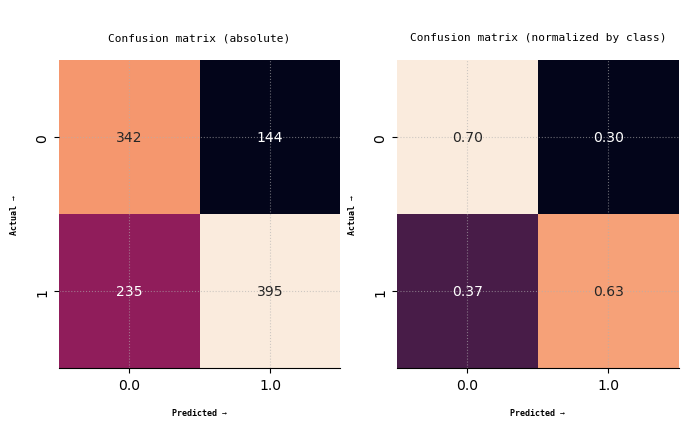

Accuracy: 0.66
Recall: 0.627
Precision: 0.733
F1: 0.676
ROC AUC: 0.665
**************************************** Caucasian ************************************* 


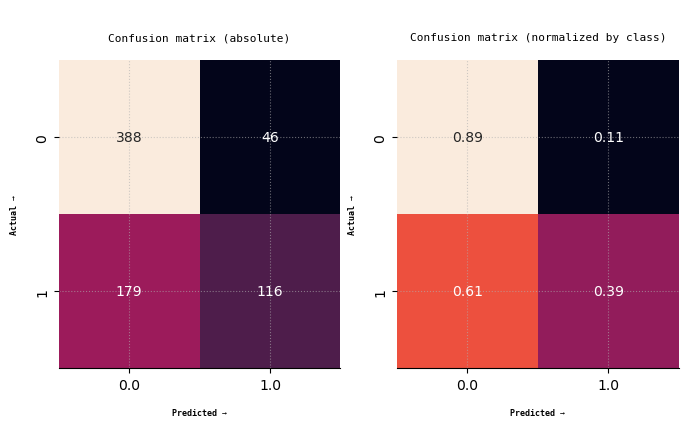

Accuracy: 0.691
Recall: 0.393
Precision: 0.716
F1: 0.508
ROC AUC: 0.644
**************************************** All ************************************* 


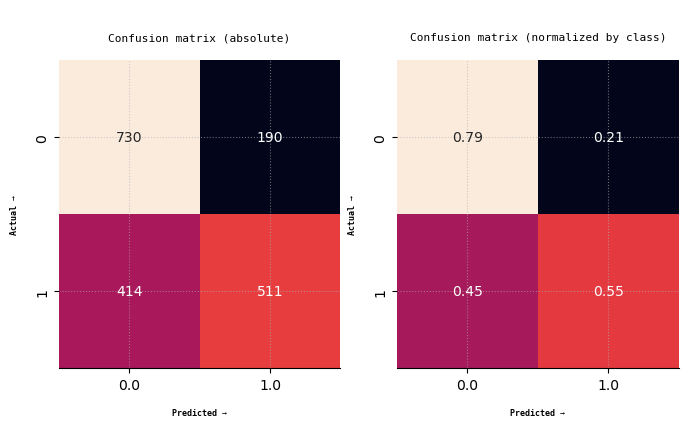

Accuracy: 0.673
Recall: 0.552
Precision: 0.729
F1: 0.629
ROC AUC: 0.673
Disparate impact: 0.46
Equal opportunity: 0.627


In [27]:
# African-American
print('*************************************** African-American ************************************ ')
print_performances(y_true=X_test1.loc[X_test1['race'] == 'African-American', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p1.loc[X_test_p1['race'] == 'African-American', 'prediction'].reset_index(drop=True))

# Caucasian
print('**************************************** Caucasian ************************************* ')
print_performances(y_true=X_test1.loc[X_test1['race'] == 'Caucasian', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p1.loc[X_test_p1['race'] == 'Caucasian', 'prediction'].reset_index(drop=True))

#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test1['is_recid'], y_hat=X_test_p1['prediction'])

#Disparate impact:
PPAA1 = (X_test_p1['prediction'][(X_test_p1['race'] == 'African-American') & (X_test_p1['prediction']==True)].count())
AA1 = (X_test_p1['prediction'][(X_test_p1['race'] == 'African-American')]).count()
PPC1 = (X_test_p1['prediction'][(X_test_p1['race'] == 'Caucasian') & (X_test_p1['prediction']==True)].count())
C1 = (X_test_p1['prediction'][(X_test_p1['race'] == 'Caucasian')]).count()
DI1 = round((PPC1/C1)/(PPAA1/AA1), 3)

#Equal opportunity:
TPAA1 = (X_test_p1['prediction'][(X_test_p1['race'] == 'African-American') & (X_test_p1['prediction']==True) & (X_test1['is_recid']==True)].count())
APAA1 = (X_test1['is_recid'][(X_test1['race'] == 'African-American') & (X_test1['is_recid']==True)].count())
TPC1 = (X_test_p1['prediction'][(X_test_p1['race'] == 'Caucasian') & (X_test_p1['prediction']==True) & (X_test1['is_recid']==True)].count())
APC1 = (X_test1['is_recid'][(X_test1['race'] == 'Caucasian') & (X_test1['is_recid']==True)].count())
EQ1 = round((TPC1/APC1)/(TPAA1/APAA1), 3)

print(f'Disparate impact: {DI1}')
print (f'Equal opportunity: {EQ1}')

In [28]:
eq1 = eq(X_test = X_test1, X_test_p = X_test_p1, actual= 'is_recid', prediction = 'prediction', 
         sens_att = 'race', priv_class = 'African-American', disc_class = 'Caucasian')

di1 = di(X_test_p= X_test_p1, prediction='prediction', sens_att='race', priv_class='African-American', disc_class='Caucasian')

eq1,di1

(0.627, 0.46)

In [29]:
di1 = di(X_test_p= X_test_p1, prediction='prediction', sens_att='race', priv_class='African-American', disc_class='Caucasian')

#### Za p=0.99

Atribut sex je već više balansiran od traženih 0.1, zadržaće se postojeći balans koji iznosi 0.18864774624373956
Atribut race je već više balansiran od traženih 0.1, zadržaće se postojeći balans koji iznosi 0.519203413940256
*************************************** African-American ************************************ 


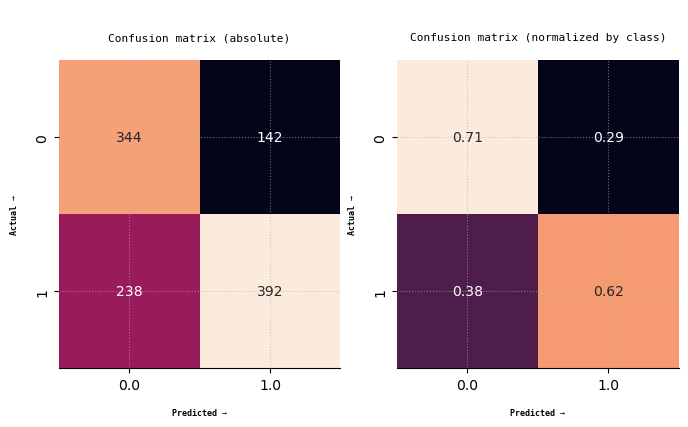

Accuracy: 0.659
Recall: 0.622
Precision: 0.734
F1: 0.674
ROC AUC: 0.665
**************************************** Caucasian ************************************* 


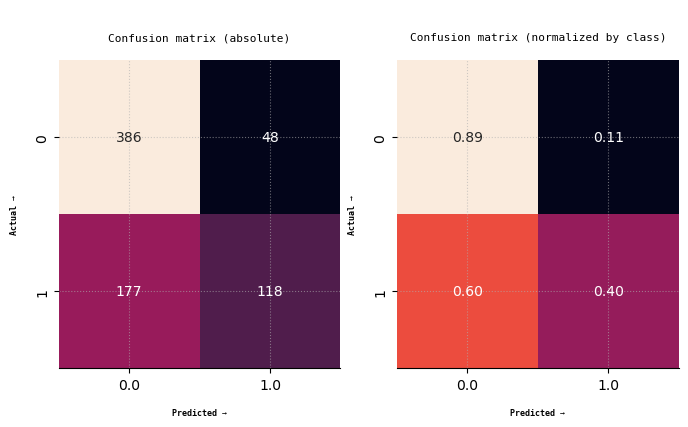

Accuracy: 0.691
Recall: 0.4
Precision: 0.711
F1: 0.512
ROC AUC: 0.645
**************************************** All ************************************* 


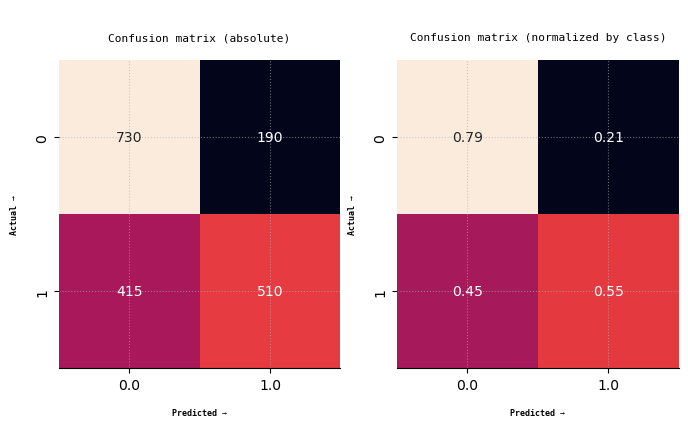

Accuracy: 0.672
Recall: 0.551
Precision: 0.729
F1: 0.628
ROC AUC: 0.672
Disparate impact: 0.476
Equal opportunity: 0.643


In [30]:
X_train2, X_test2 = train_test_split(data, test_size=0.3, random_state=297)
X_train2, X_test2 = X_train2.reset_index(drop=True), X_test2.reset_index(drop=True)

X_test_p2 = X_test2.drop('is_recid', axis=1)

model2 = fit(data=X_train2, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex' ], p=0.1)


for i in range(len(X_test_p2)):
    prediction2, confidence2 = predict(model2, X_test_p2.loc[i])
    
    X_test_p2.loc[i,'prediction'] = prediction2
    
    for klasa in confidence2:
        X_test_p2.loc[i,'class='+str(klasa)] = confidence2[klasa]

# African-American
print('*************************************** African-American ************************************ ')
print_performances(y_true=X_test2.loc[X_test2['race'] == 'African-American', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p2.loc[X_test_p2['race'] == 'African-American', 'prediction'].reset_index(drop=True))

# Caucasian
print('**************************************** Caucasian ************************************* ')
print_performances(y_true=X_test2.loc[X_test2['race'] == 'Caucasian', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p2.loc[X_test_p2['race'] == 'Caucasian', 'prediction'].reset_index(drop=True))

#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test2['is_recid'], y_hat=X_test_p2['prediction'])

#Disparate impact:
PPAA2 = (X_test_p2['prediction'][(X_test_p2['race'] == 'African-American') & (X_test_p2['prediction']==True)].count())
AA2 = (X_test_p2['prediction'][(X_test_p2['race'] == 'African-American')]).count()
PPC2 = (X_test_p2['prediction'][(X_test_p2['race'] == 'Caucasian') & (X_test_p2['prediction']==True)].count())
C2 = (X_test_p2['prediction'][(X_test_p2['race'] == 'Caucasian')]).count()
DI2 = round((PPC2/C2)/(PPAA2/AA2), 3)

#Equal opportunity:
TPAA2 = (X_test_p2['prediction'][(X_test_p2['race'] == 'African-American') & (X_test_p2['prediction']==True) & (X_test2['is_recid']==True)].count())
APAA2 = (X_test2['is_recid'][(X_test2['race'] == 'African-American') & (X_test2['is_recid']==True)].count())
TPC2 = (X_test_p2['prediction'][(X_test_p2['race'] == 'Caucasian') & (X_test_p2['prediction']==True) & (X_test2['is_recid']==True)].count())
APC2 = (X_test2['is_recid'][(X_test2['race'] == 'Caucasian') & (X_test2['is_recid']==True)].count())
EQ2 = round((TPC2/APC2)/(TPAA2/APAA2), 3)


print(f'Disparate impact: {DI2}')
print (f'Equal opportunity: {EQ2}')

### Pomeranje granice odlučivanja

#### Threshold = 0,3 

**************************************** All ************************************* 


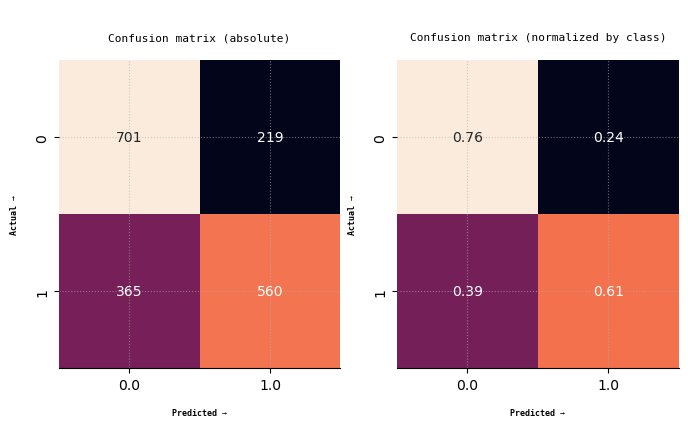

Accuracy: 0.683
Recall: 0.605
Precision: 0.719
F1: 0.657
ROC AUC: 0.684
Disparate impact: 0.508
Equal opportunity: 0.678


In [31]:
X_train3, X_test3 = train_test_split(data, test_size=0.3, random_state=297)
X_train3, X_test3 = X_train3.reset_index(drop=True), X_test3.reset_index(drop=True)

X_test_p3 = X_test3.drop('is_recid', axis=1)

model3 = fit(data=X_train3, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex'], p=0.99)


for i in range(len(X_test_p3)):
    prediction3, confidence3 = predict(model=model3, new_instance=X_test_p3.loc[i], target_class=1, threshold=0.3)
    
    X_test_p3.loc[i,'prediction'] = prediction3
    
    for klasa in confidence3:
        X_test_p3.loc[i,'class='+str(klasa)] = confidence3[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test3['is_recid'], y_hat=X_test_p3['prediction'])

#Disparate impact:
PPAA3 = (X_test_p3['prediction'][(X_test_p3['race'] == 'African-American') & (X_test_p3['prediction']==True)].count())
AA3 = (X_test_p3['prediction'][(X_test_p3['race'] == 'African-American')]).count()
PPC3 = (X_test_p3['prediction'][(X_test_p3['race'] == 'Caucasian') & (X_test_p3['prediction']==True)].count())
C3 = (X_test_p3['prediction'][(X_test_p3['race'] == 'Caucasian')]).count()
DI3 = round((PPC3/C3)/(PPAA3/AA3), 3)

#Equal opportunity:
TPAA3 = (X_test_p3['prediction'][(X_test_p3['race'] == 'African-American') & (X_test_p3['prediction']==True) & (X_test3['is_recid']==True)].count())
APAA3 = (X_test3['is_recid'][(X_test3['race'] == 'African-American') & (X_test3['is_recid']==True)].count())
TPC3 = (X_test_p3['prediction'][(X_test_p3['race'] == 'Caucasian') & (X_test_p3['prediction']==True) & (X_test3['is_recid']==True)].count())
APC3 = (X_test3['is_recid'][(X_test3['race'] == 'Caucasian') & (X_test3['is_recid']==True)].count())
EQ3 = round((TPC3/APC3)/(TPAA3/APAA3), 3)


print(f'Disparate impact: {DI3}')
print (f'Equal opportunity: {EQ3}')

#### Threshold = 0,4 

**************************************** All ************************************* 


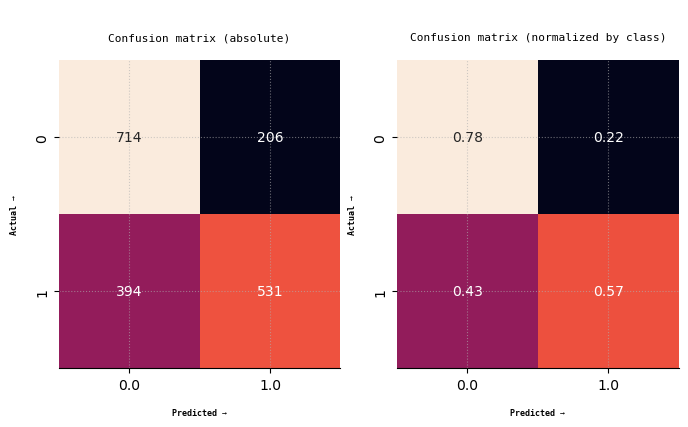

Accuracy: 0.675
Recall: 0.574
Precision: 0.72
F1: 0.639
ROC AUC: 0.675
Disparate impact: 0.491
Equal opportunity: 0.658


In [32]:
X_train4, X_test4 = train_test_split(data, test_size=0.3, random_state=297)
X_train4, X_test4 = X_train4.reset_index(drop=True), X_test4.reset_index(drop=True)

X_test_p4 = X_test4.drop('is_recid', axis=1)

model4 = fit(data=X_train4, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex'], p=0.99)


for i in range(len(X_test_p4)):
    prediction4, confidence4 = predict(model=model4, new_instance=X_test_p4.loc[i], target_class=1, threshold=0.4)
    
    X_test_p4.loc[i,'prediction'] = prediction4
    
    for klasa in confidence4:
        X_test_p4.loc[i,'class='+str(klasa)] = confidence4[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test4['is_recid'], y_hat=X_test_p4['prediction'])

#Disparate impact:
PPAA4 = (X_test_p4['prediction'][(X_test_p4['race'] == 'African-American') & (X_test_p4['prediction']==True)].count())
AA4 = (X_test_p4['prediction'][(X_test_p4['race'] == 'African-American')]).count()
PPC4 = (X_test_p4['prediction'][(X_test_p4['race'] == 'Caucasian') & (X_test_p4['prediction']==True)].count())
C4 = (X_test_p4['prediction'][(X_test_p4['race'] == 'Caucasian')]).count()
DI4 = round((PPC4/C4)/(PPAA4/AA4), 3)

#Equal opportunity:
TPAA4 = (X_test_p4['prediction'][(X_test_p4['race'] == 'African-American') & (X_test_p4['prediction']==True) & (X_test4['is_recid']==True)].count())
APAA4 = (X_test4['is_recid'][(X_test4['race'] == 'African-American') & (X_test4['is_recid']==True)].count())
TPC4 = (X_test_p4['prediction'][(X_test_p4['race'] == 'Caucasian') & (X_test_p4['prediction']==True) & (X_test4['is_recid']==True)].count())
APC4 = (X_test4['is_recid'][(X_test4['race'] == 'Caucasian') & (X_test4['is_recid']==True)].count())
EQ4 = round((TPC4/APC4)/(TPAA4/APAA4), 3)


print(f'Disparate impact: {DI4}')
print (f'Equal opportunity: {EQ4}')

#### Threshold = 0,6

**************************************** All ************************************* 


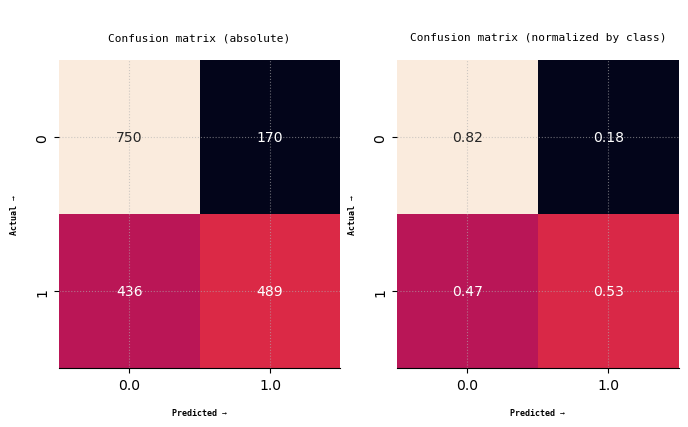

Accuracy: 0.672
Recall: 0.529
Precision: 0.742
F1: 0.617
ROC AUC: 0.672
Disparate impact: 0.467
Equal opportunity: 0.62


In [33]:
X_train5, X_test5 = train_test_split(data, test_size=0.3, random_state=297)
X_train5, X_test5 = X_train5.reset_index(drop=True), X_test5.reset_index(drop=True)

X_test_p5 = X_test5.drop('is_recid', axis=1)

model5 = fit(data=X_train5, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex'], p=0.99)


for i in range(len(X_test_p5)):
    prediction5, confidence5 = predict(model=model5, new_instance=X_test_p5.loc[i], target_class=1, threshold=0.6)
    
    X_test_p5.loc[i,'prediction'] = prediction5
    
    for klasa in confidence5:
        X_test_p5.loc[i,'class='+str(klasa)] = confidence5[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test5['is_recid'], y_hat=X_test_p5['prediction'])

#Disparate impact:
PPAA5 = (X_test_p5['prediction'][(X_test_p5['race'] == 'African-American') & (X_test_p5['prediction']==True)].count())
AA5 = (X_test_p5['prediction'][(X_test_p5['race'] == 'African-American')]).count()
PPC5 = (X_test_p5['prediction'][(X_test_p5['race'] == 'Caucasian') & (X_test_p5['prediction']==True)].count())
C5 = (X_test_p5['prediction'][(X_test_p5['race'] == 'Caucasian')]).count()
DI5 = round((PPC5/C5)/(PPAA5/AA5), 3)

#Equal opportunity:
TPAA5 = (X_test_p5['prediction'][(X_test_p5['race'] == 'African-American') & (X_test_p5['prediction']==True) & (X_test5['is_recid']==True)].count())
APAA5 = (X_test5['is_recid'][(X_test5['race'] == 'African-American') & (X_test5['is_recid']==True)].count())
TPC5 = (X_test_p5['prediction'][(X_test_p5['race'] == 'Caucasian') & (X_test_p5['prediction']==True) & (X_test5['is_recid']==True)].count())
APC5 = (X_test5['is_recid'][(X_test5['race'] == 'Caucasian') & (X_test5['is_recid']==True)].count())
EQ5 = round((TPC5/APC5)/(TPAA5/APAA5), 3)


print(f'Disparate impact: {DI5}')
print (f'Equal opportunity: {EQ5}')

#### Threshold = 0,7

**************************************** All ************************************* 


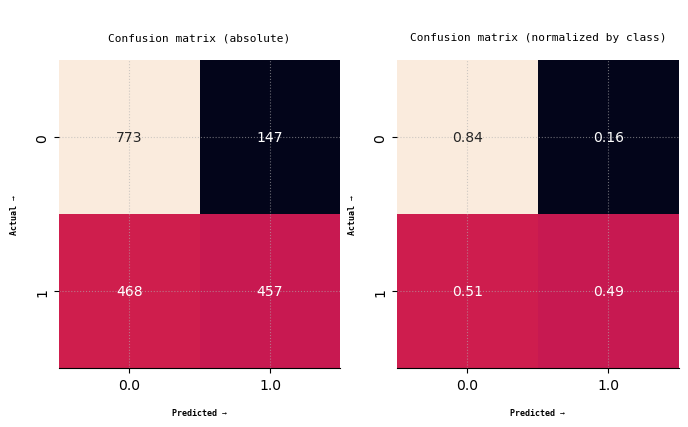

Accuracy: 0.667
Recall: 0.494
Precision: 0.757
F1: 0.598
ROC AUC: 0.667
Disparate impact: 0.449
Equal opportunity: 0.606


In [34]:
X_train6, X_test6 = train_test_split(data, test_size=0.3, random_state=297)
X_train6, X_test6 = X_train6.reset_index(drop=True), X_test6.reset_index(drop=True)

X_test_p6 = X_test6.drop('is_recid', axis=1)

model6 = fit(data=X_train6, class_att='is_recid', positive_class = 1, alpha=5, sensitive_att=['race', 'sex'], p=0.99)


for i in range(len(X_test_p6)):
    prediction6, confidence6 = predict(model=model6, new_instance=X_test_p6.loc[i], target_class=1, threshold=0.7)
    
    X_test_p6.loc[i,'prediction'] = prediction6
    
    for klasa in confidence6:
        X_test_p6.loc[i,'class='+str(klasa)] = confidence6[klasa]


#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test6['is_recid'], y_hat=X_test_p6['prediction'])

#Disparate impact:
PPAA6 = (X_test_p6['prediction'][(X_test_p6['race'] == 'African-American') & (X_test_p6['prediction']==True)].count())
AA6 = (X_test_p6['prediction'][(X_test_p6['race'] == 'African-American')]).count()
PPC6 = (X_test_p6['prediction'][(X_test_p6['race'] == 'Caucasian') & (X_test_p6['prediction']==True)].count())
C6 = (X_test_p6['prediction'][(X_test_p6['race'] == 'Caucasian')]).count()
DI6 = round((PPC6/C6)/(PPAA6/AA6), 3)

#Equal opportunity:
TPAA6 = (X_test_p6['prediction'][(X_test_p6['race'] == 'African-American') & (X_test_p6['prediction']==True) & (X_test6['is_recid']==True)].count())
APAA6 = (X_test6['is_recid'][(X_test6['race'] == 'African-American') & (X_test6['is_recid']==True)].count())
TPC6 = (X_test_p6['prediction'][(X_test_p6['race'] == 'Caucasian') & (X_test_p6['prediction']==True) & (X_test6['is_recid']==True)].count())
APC6 = (X_test6['is_recid'][(X_test6['race'] == 'Caucasian') & (X_test6['is_recid']==True)].count())
EQ6 = round((TPC6/APC6)/(TPAA6/APAA6), 3)


print(f'Disparate impact: {DI6}')
print (f'Equal opportunity: {EQ6}')

#### Threshold = 0,8

*************************************** African-American ************************************ 


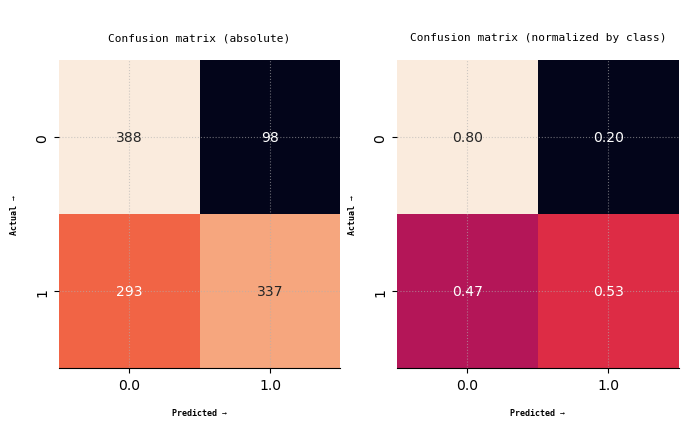

Accuracy: 0.65
Recall: 0.535
Precision: 0.775
F1: 0.633
ROC AUC: 0.667
**************************************** Caucasian ************************************* 


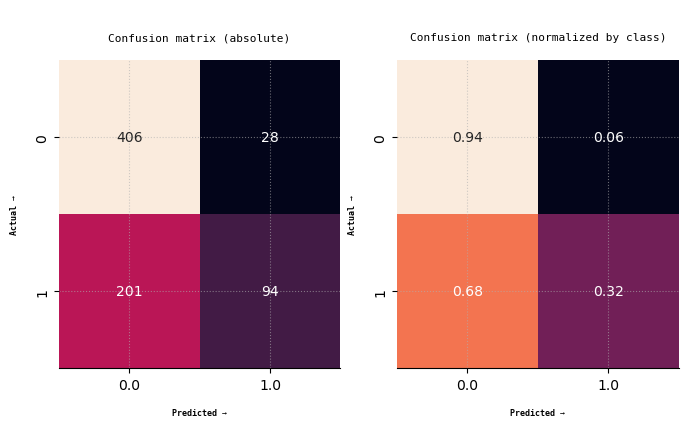

Accuracy: 0.686
Recall: 0.319
Precision: 0.77
F1: 0.451
ROC AUC: 0.627
**************************************** All ************************************* 


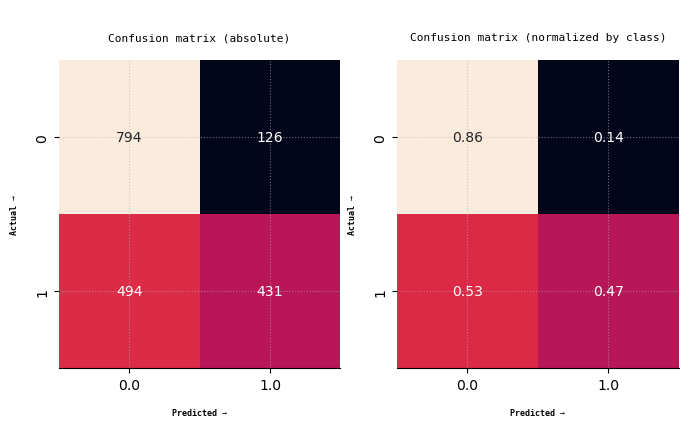

Accuracy: 0.664
Recall: 0.466
Precision: 0.774
F1: 0.582
ROC AUC: 0.664
Disparate impact: 0.429
Equal opportunity: 0.596


In [35]:
X_train7, X_test7 = train_test_split(data, test_size=0.3, random_state=297)
X_train7, X_test7 = X_train7.reset_index(drop=True), X_test7.reset_index(drop=True)

X_test_p7 = X_test7.drop('is_recid', axis=1)

model7 = fit(data=X_train7, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex'], p=0.99)


for i in range(len(X_test_p7)):
    prediction7, confidence7 = predict(model=model7, new_instance=X_test_p7.loc[i], target_class=1, threshold=0.8)
    
    X_test_p7.loc[i,'prediction'] = prediction7
    
    for klasa in confidence7:
        X_test_p7.loc[i,'class='+str(klasa)] = confidence7[klasa]

# African-American
print('*************************************** African-American ************************************ ')
print_performances(y_true=X_test7.loc[X_test7['race'] == 'African-American', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p7.loc[X_test_p7['race'] == 'African-American', 'prediction'].reset_index(drop=True))

# Caucasian
print('**************************************** Caucasian ************************************* ')
print_performances(y_true=X_test7.loc[X_test7['race'] == 'Caucasian', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p7.loc[X_test_p7['race'] == 'Caucasian', 'prediction'].reset_index(drop=True))
        
#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test7['is_recid'], y_hat=X_test_p7['prediction'])

#Disparate impact:
PPAA7 = (X_test_p7['prediction'][(X_test_p7['race'] == 'African-American') & (X_test_p7['prediction']==True)].count())
AA7 = (X_test_p7['prediction'][(X_test_p7['race'] == 'African-American')]).count()
PPC7 = (X_test_p7['prediction'][(X_test_p7['race'] == 'Caucasian') & (X_test_p7['prediction']==True)].count())
C7 = (X_test_p7['prediction'][(X_test_p7['race'] == 'Caucasian')]).count()
DI7 = round((PPC7/C7)/(PPAA7/AA7), 3)

#Equal opportunity:
TPAA7 = (X_test_p7['prediction'][(X_test_p7['race'] == 'African-American') & (X_test_p7['prediction']==True) & (X_test7['is_recid']==True)].count())
APAA7 = (X_test7['is_recid'][(X_test7['race'] == 'African-American') & (X_test7['is_recid']==True)].count())
TPC7 = (X_test_p7['prediction'][(X_test_p7['race'] == 'Caucasian') & (X_test_p7['prediction']==True) & (X_test7['is_recid']==True)].count())
APC7 = (X_test7['is_recid'][(X_test7['race'] == 'Caucasian') & (X_test7['is_recid']==True)].count())
EQ7 = round((TPC7/APC7)/(TPAA7/APAA7), 3)


print(f'Disparate impact: {DI7}')
print (f'Equal opportunity: {EQ7}')

#### Threshold = 0,005

*************************************** African-American ************************************ 


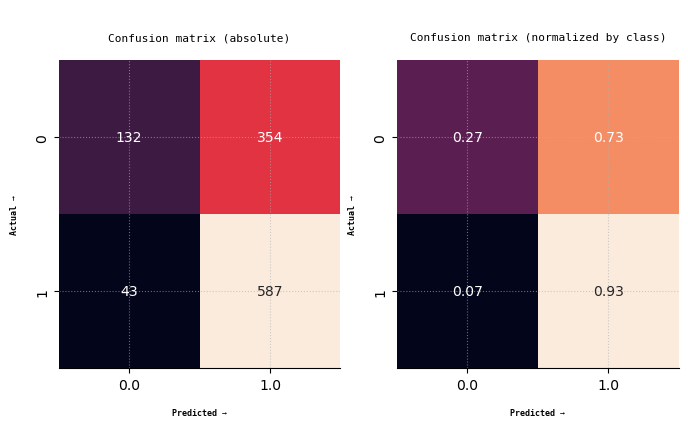

Accuracy: 0.644
Recall: 0.932
Precision: 0.624
F1: 0.747
ROC AUC: 0.602
**************************************** Caucasian ************************************* 


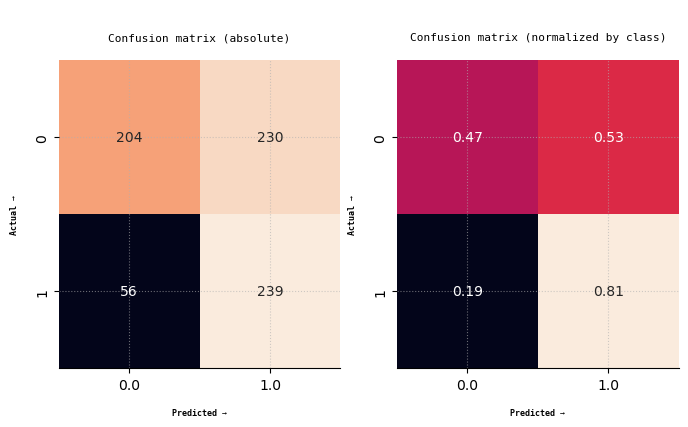

Accuracy: 0.608
Recall: 0.81
Precision: 0.51
F1: 0.626
ROC AUC: 0.64
**************************************** All ************************************* 


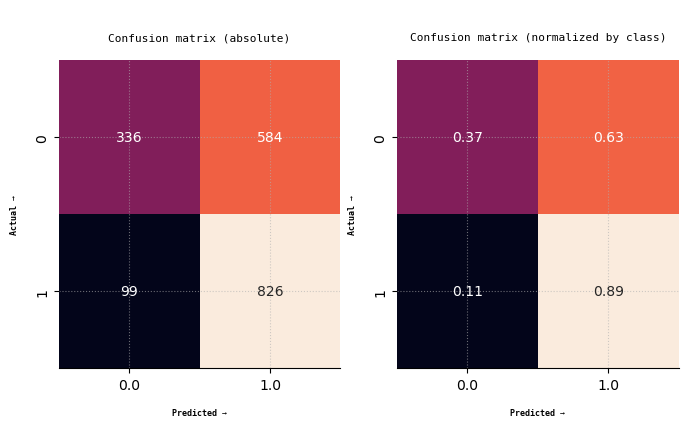

Accuracy: 0.63
Recall: 0.893
Precision: 0.586
F1: 0.707
ROC AUC: 0.629
Disparate impact: 0.763
Equal opportunity: 0.87


In [36]:
X_train8, X_test8 = train_test_split(data, test_size=0.3, random_state=297)
X_train8, X_test8 = X_train8.reset_index(drop=True), X_test8.reset_index(drop=True)

X_test_p8 = X_test8.drop('is_recid', axis=1)

model8 = fit(data=X_train8, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex'], p=0.99)


for i in range(len(X_test_p8)):
    prediction8, confidence8 = predict(model=model8, new_instance=X_test_p8.loc[i], target_class=1, threshold=0.005)
    
    X_test_p8.loc[i,'prediction'] = prediction8
    
    for klasa in confidence8:
        X_test_p8.loc[i,'class='+str(klasa)] = confidence8[klasa]

# African-American
print('*************************************** African-American ************************************ ')
print_performances(y_true=X_test8.loc[X_test8['race'] == 'African-American', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p8.loc[X_test_p8['race'] == 'African-American', 'prediction'].reset_index(drop=True))

# Caucasian
print('**************************************** Caucasian ************************************* ')
print_performances(y_true=X_test8.loc[X_test8['race'] == 'Caucasian', 'is_recid'].reset_index(drop=True),
                   y_hat=X_test_p8.loc[X_test_p8['race'] == 'Caucasian', 'prediction'].reset_index(drop=True))
        
#ALL
print('**************************************** All ************************************* ')
print_performances(y_true=X_test8['is_recid'], y_hat=X_test_p8['prediction'])

#Disparate impact:
PPAA8 = (X_test_p8['prediction'][(X_test_p8['race'] == 'African-American') & (X_test_p8['prediction']==True)].count())
AA8 = (X_test_p8['prediction'][(X_test_p8['race'] == 'African-American')]).count()
PPC8 = (X_test_p8['prediction'][(X_test_p8['race'] == 'Caucasian') & (X_test_p8['prediction']==True)].count())
C8 = (X_test_p8['prediction'][(X_test_p8['race'] == 'Caucasian')]).count()
DI8 = round((PPC8/C8)/(PPAA8/AA8), 3)

#Equal opportunity:
TPAA8 = (X_test_p8['prediction'][(X_test_p8['race'] == 'African-American') & (X_test_p8['prediction']==True) & (X_test8['is_recid']==True)].count())
APAA8 = (X_test8['is_recid'][(X_test8['race'] == 'African-American') & (X_test8['is_recid']==True)].count())
TPC8 = (X_test_p8['prediction'][(X_test_p8['race'] == 'Caucasian') & (X_test_p8['prediction']==True) & (X_test8['is_recid']==True)].count())
APC8 = (X_test8['is_recid'][(X_test8['race'] == 'Caucasian') & (X_test8['is_recid']==True)].count())
EQ8 = round((TPC8/APC8)/(TPAA8/APAA8), 3)


print(f'Disparate impact: {DI8}')
print (f'Equal opportunity: {EQ8}')

# Optimizacija parametara

In [37]:
time_started = datetime.now()

X_train, X_test = train_test_split(data, test_size=0.3, random_state=297)
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)
X_test_p = X_test.drop('is_recid', axis=1)

p_params = np.linspace(start=0, stop=0.99, num=20)
p_params = np.round(p_params, 3)
t_params = np.linspace(start=0, stop=1, num=20)
t_params = np.round(t_params, 3)


DI=pd.DataFrame(data=None, index=p_params, columns=t_params)
EQ=pd.DataFrame(data=None, index=p_params, columns=t_params)
Acc=pd.DataFrame(data=None, index=p_params, columns=t_params)
Rec=pd.DataFrame(data=None, index=p_params, columns=t_params)
Prec=pd.DataFrame(data=None, index=p_params, columns=t_params)
F1=pd.DataFrame(data=None, index=p_params, columns=t_params)
AUC=pd.DataFrame(data=None, index=p_params, columns=t_params)



for pp in p_params:
    model = fit(data=X_train, class_att='is_recid', positive_class = 1, alpha=10, sensitive_att=['race', 'sex'], p=pp)
    for t in t_params: 
        for i in range(len(X_test_p)):
            prediction, confidence = predict(model=model, new_instance=X_test_p.loc[i], target_class=1, threshold=t)
            X_test_p.loc[i,'prediction'] = prediction   
                
        DI.loc[pp, t] = di(X_test_p = X_test_p, prediction='prediction', sens_att='race', priv_class='African-American', disc_class='Caucasian')
        EQ.loc[pp, t] = eq(X_test=X_test, X_test_p=X_test_p, actual='is_recid', prediction='prediction', sens_att='race', priv_class='African-American', disc_class='Caucasian')
        Acc.loc[pp, t] = round(accuracy_score(y_true=X_test['is_recid'], y_pred=X_test_p['prediction']),3)
        Rec.loc[pp, t] = round(recall_score(y_true=X_test['is_recid'], y_pred=X_test_p['prediction']), 3)
        Prec.loc[pp, t] = round(precision_score(y_true=X_test['is_recid'], y_pred=X_test_p['prediction']), 3)
        F1.loc[pp, t] = round(f1_score(y_true=X_test['is_recid'], y_pred=X_test_p['prediction']), 3)
        AUC.loc[pp, t] = round(roc_auc_score(y_true=X_test['is_recid'], y_score=X_test_p['prediction']), 3)
                
        print(f'Završeno za: p={pp} i t={t}')
        
print(DI, EQ, Acc, Rec, Prec, F1, AUC)
time_finished = datetime.now()
run_last = (time_finished - time_started).seconds / 60
print(f'-----------------------------\nVreme izvršavanja: {run_last} mins.')

Atribut sex je već više balansiran od traženih 0.0, zadržaće se postojeći balans koji iznosi 0.18864774624373956
Atribut race je već više balansiran od traženih 0.0, zadržaće se postojeći balans koji iznosi 0.519203413940256
Završeno za: p=0.0 i t=0.0
Završeno za: p=0.0 i t=0.053
Završeno za: p=0.0 i t=0.105
Završeno za: p=0.0 i t=0.158
Završeno za: p=0.0 i t=0.211
Završeno za: p=0.0 i t=0.263
Završeno za: p=0.0 i t=0.316
Završeno za: p=0.0 i t=0.368
Završeno za: p=0.0 i t=0.421
Završeno za: p=0.0 i t=0.474
Završeno za: p=0.0 i t=0.526
Završeno za: p=0.0 i t=0.579
Završeno za: p=0.0 i t=0.632
Završeno za: p=0.0 i t=0.684
Završeno za: p=0.0 i t=0.737
Završeno za: p=0.0 i t=0.789
Završeno za: p=0.0 i t=0.842
Završeno za: p=0.0 i t=0.895
Završeno za: p=0.0 i t=0.947
Završeno za: p=0.0 i t=1.0
Atribut sex je već više balansiran od traženih 0.052, zadržaće se postojeći balans koji iznosi 0.18864774624373956
Atribut race je već više balansiran od traženih 0.052, zadržaće se postojeći balans 

Završeno za: p=0.521 i t=0.842
Završeno za: p=0.521 i t=0.895
Završeno za: p=0.521 i t=0.947
Završeno za: p=0.521 i t=1.0
Završeno za: p=0.573 i t=0.0
Završeno za: p=0.573 i t=0.053
Završeno za: p=0.573 i t=0.105
Završeno za: p=0.573 i t=0.158
Završeno za: p=0.573 i t=0.211
Završeno za: p=0.573 i t=0.263
Završeno za: p=0.573 i t=0.316
Završeno za: p=0.573 i t=0.368
Završeno za: p=0.573 i t=0.421
Završeno za: p=0.573 i t=0.474
Završeno za: p=0.573 i t=0.526
Završeno za: p=0.573 i t=0.579
Završeno za: p=0.573 i t=0.632
Završeno za: p=0.573 i t=0.684
Završeno za: p=0.573 i t=0.737
Završeno za: p=0.573 i t=0.789
Završeno za: p=0.573 i t=0.842
Završeno za: p=0.573 i t=0.895
Završeno za: p=0.573 i t=0.947
Završeno za: p=0.573 i t=1.0
Završeno za: p=0.625 i t=0.0
Završeno za: p=0.625 i t=0.053
Završeno za: p=0.625 i t=0.105
Završeno za: p=0.625 i t=0.158
Završeno za: p=0.625 i t=0.211
Završeno za: p=0.625 i t=0.263
Završeno za: p=0.625 i t=0.316
Završeno za: p=0.625 i t=0.368
Završeno za: p=0

In [38]:
DI

,0.000,0.053,0.105,0.158,0.211,0.263,0.316,0.368,0.421,0.474,0.526,0.579,0.632,0.684,0.737,0.789,0.842,0.895,0.947,1.000
0.000,1.003,0.625,0.593,0.569,0.543,0.521,0.506,0.491,0.486,0.473,0.472,0.466,0.468,0.451,0.454,0.435,0.422,0.407,0.361,0.247
0.052,1.003,0.625,0.593,0.569,0.543,0.521,0.506,0.491,0.486,0.473,0.472,0.466,0.468,0.451,0.454,0.435,0.422,0.407,0.361,0.247
0.104,1.003,0.625,0.593,0.569,0.543,0.521,0.506,0.491,0.486,0.473,0.472,0.466,0.468,0.451,0.454,0.435,0.422,0.407,0.361,0.247
0.156,1.003,0.625,0.593,0.569,0.543,0.521,0.506,0.491,0.486,0.473,0.472,0.466,0.468,0.451,0.454,0.435,0.422,0.407,0.361,0.247
0.208,1.003,0.623,0.582,0.569,0.536,0.516,0.509,0.496,0.484,0.472,0.464,0.458,0.458,0.454,0.436,0.445,0.423,0.397,0.353,0.247
0.261,1.003,0.625,0.587,0.571,0.542,0.516,0.509,0.497,0.485,0.474,0.463,0.46,0.46,0.461,0.434,0.444,0.423,0.397,0.355,0.247
0.313,1.003,0.625,0.587,0.571,0.543,0.516,0.509,0.497,0.484,0.475,0.465,0.46,0.459,0.463,0.433,0.444,0.418,0.394,0.353,0.247
0.365,1.003,0.627,0.593,0.574,0.548,0.516,0.508,0.497,0.484,0.476,0.462,0.46,0.461,0.46,0.436,0.441,0.418,0.394,0.353,0.247
0.417,1.003,0.626,0.595,0.574,0.548,0.516,0.511,0.497,0.482,0.476,0.465,0.46,0.465,0.457,0.436,0.441,0.418,0.394,0.353,0.247
0.469,1.003,0.628,0.595,0.574,0.548,0.516,0.51,0.494,0.482,0.475,0.469,0.46,0.464,0.456,0.437,0.441,0.418,0.394,0.353,0.247


In [39]:
DIHM = DI.astype('float64')
EQHM = EQ.astype('float64')

<AxesSubplot:>

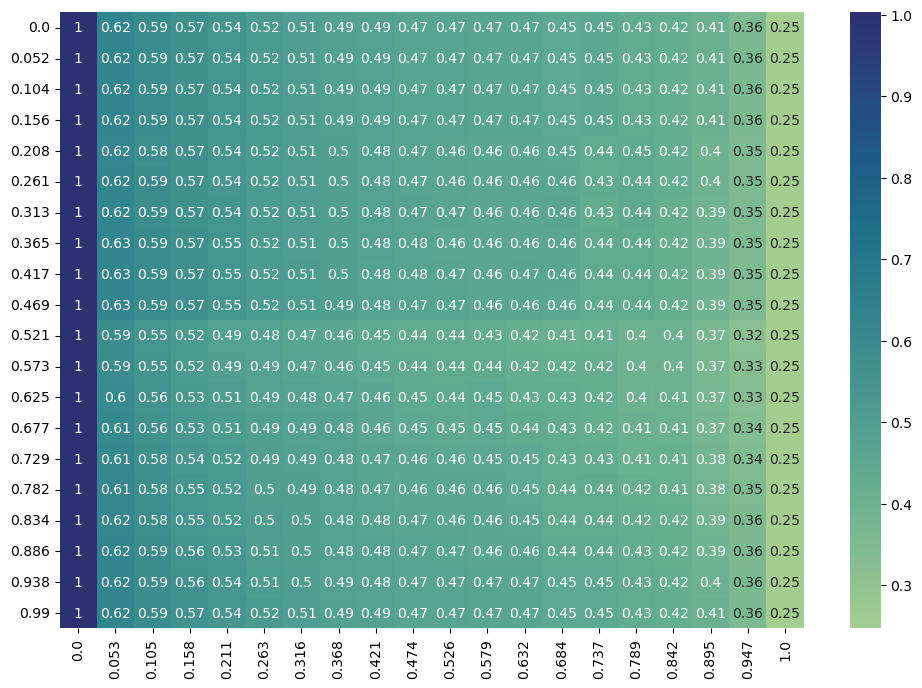

In [40]:
plt.subplots(figsize=(12, 8))
sns.heatmap(data=DIHM, annot=True, cmap="crest")

<AxesSubplot:>

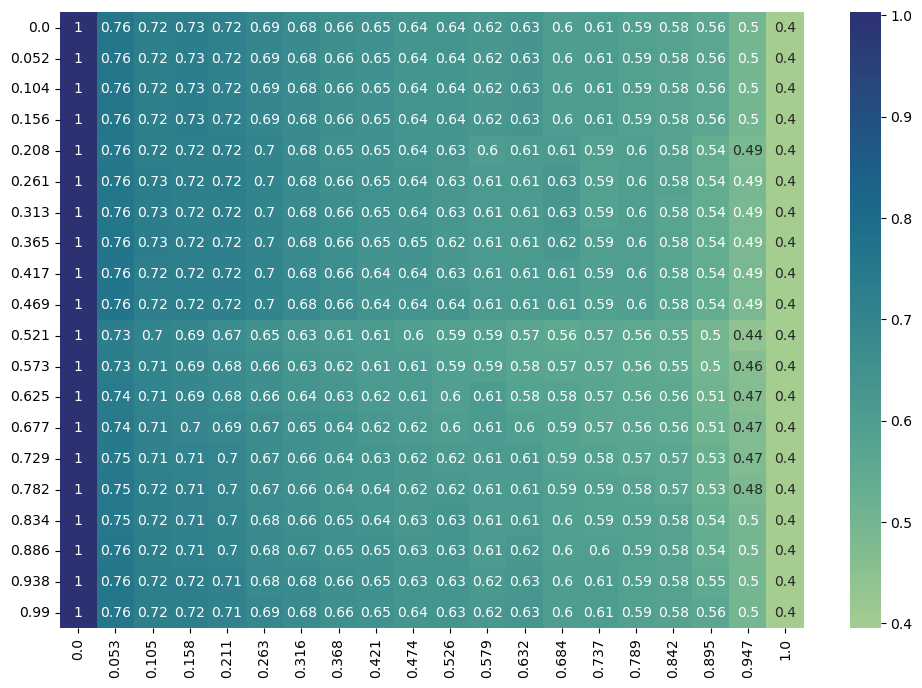

In [41]:
plt.subplots(figsize=(12,8))
sns.heatmap(data=EQHM, annot=True, cmap="crest")

#### Mere tačnosti

In [42]:
Accc = Acc.astype('float64')
Recc = Rec.astype('float64')
Precc = Prec.astype('float')
F1c = F1.astype('float64')
AUCc = AUC.astype('float64')

Accuracy:


<AxesSubplot:>

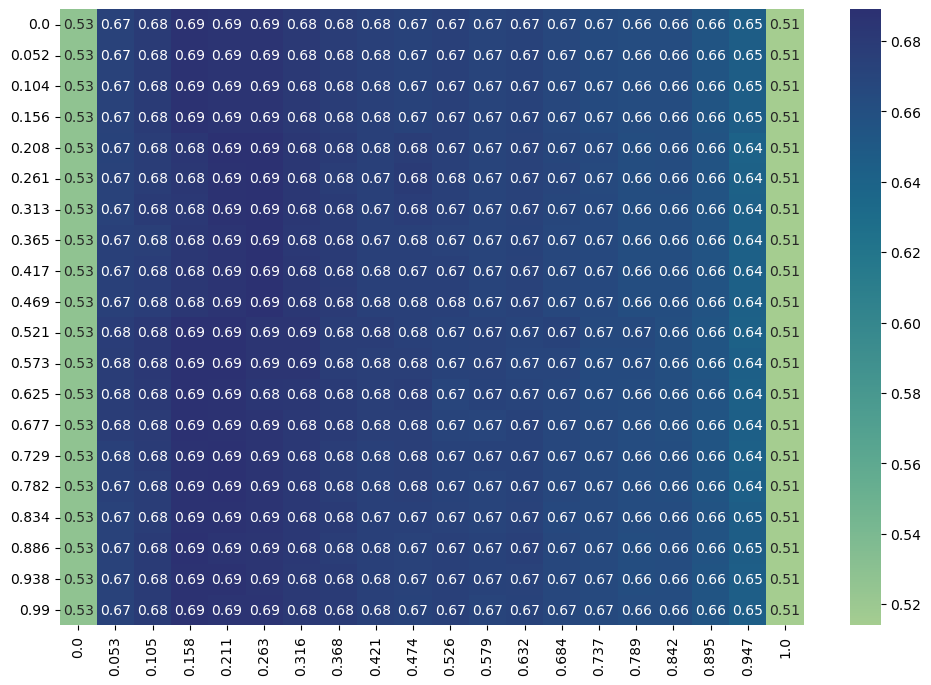

In [43]:
print('Accuracy:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=Accc, annot=True, cmap="crest")

Recall:


<AxesSubplot:>

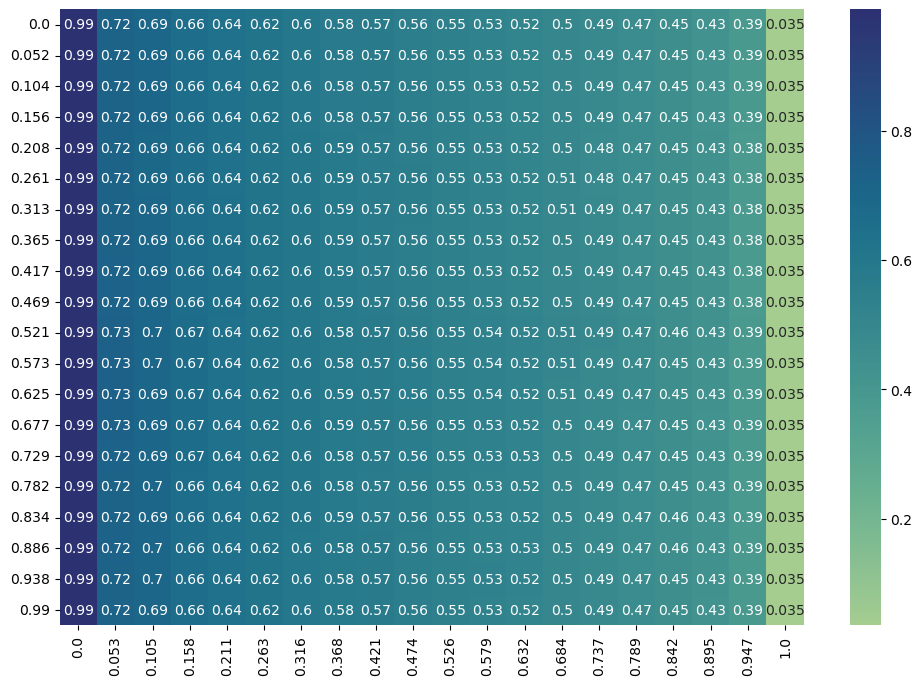

In [44]:
print('Recall:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=Recc, annot=True, cmap="crest")

Precision:


<AxesSubplot:>

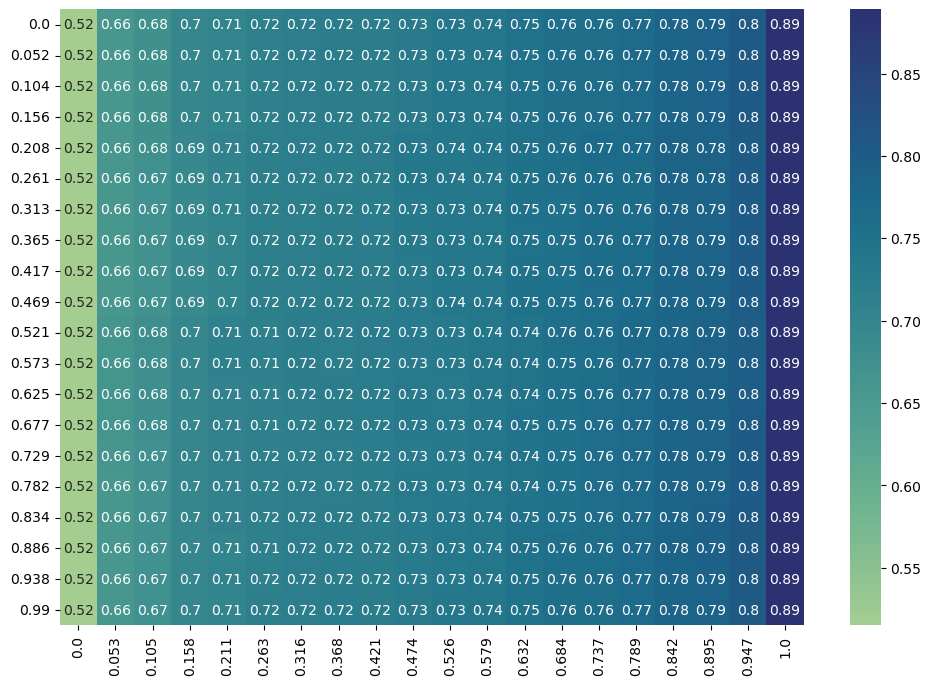

In [45]:
print('Precision:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=Precc, annot=True, cmap="crest")

F1:


<AxesSubplot:>

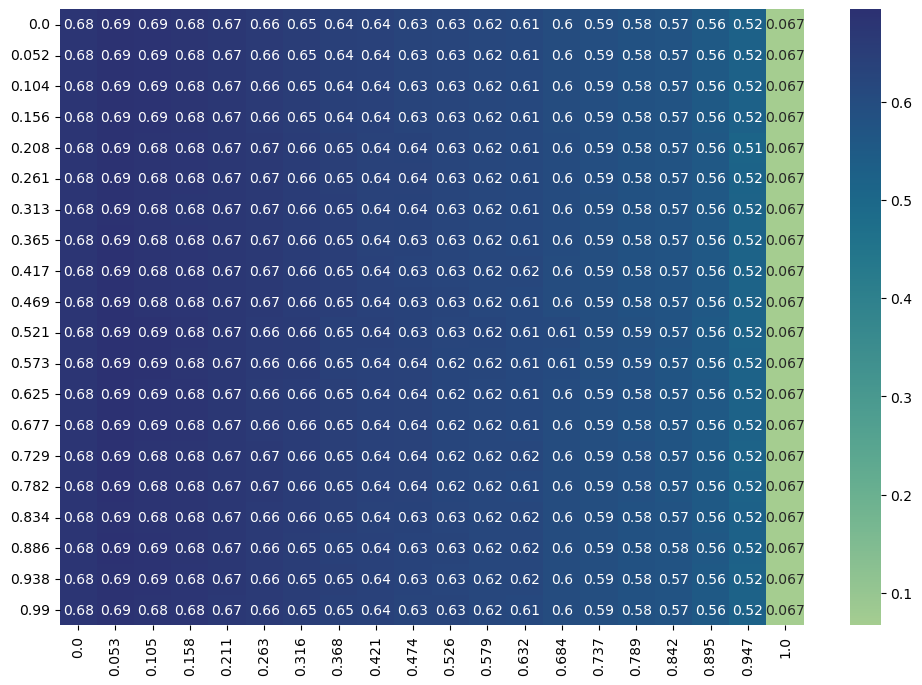

In [46]:
print('F1:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=F1c, annot=True, cmap="crest")

AUC:


<AxesSubplot:>

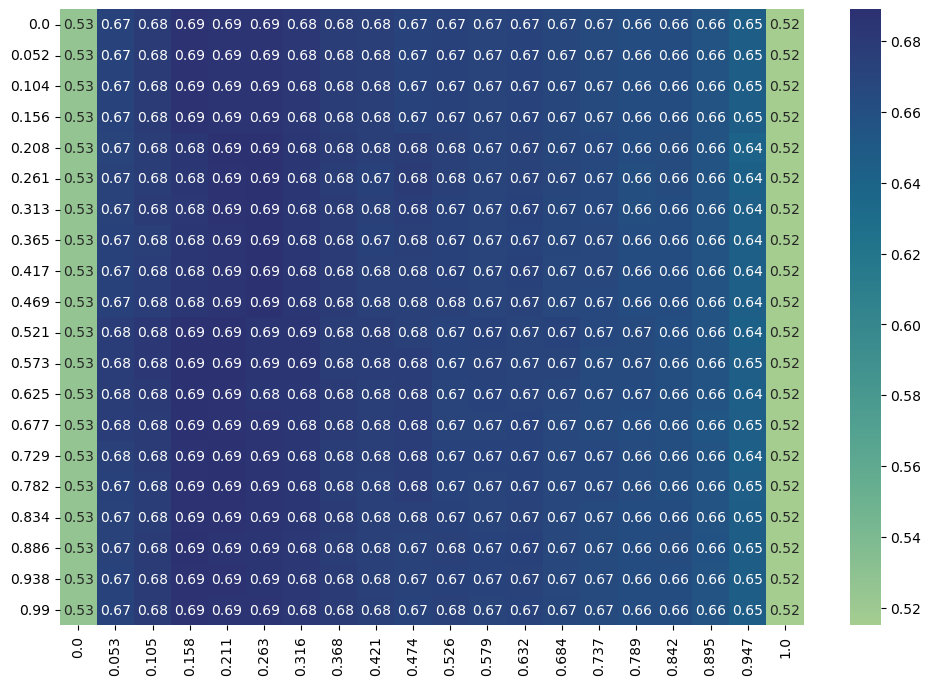

In [47]:
print('AUC:')
plt.subplots(figsize=(12,8))
sns.heatmap(data=AUCc, annot=True, cmap="crest")

Poredjenjem vrednosti mera diskriminacije uočavamo da se najbolji rezultati postižu u ekstremnim vrednostima parametara. Medjutim, vrednosti mera tačnosti, pri takvim vrednostima parametara, se drastično smanjuju. Ovo je bilo očekivano, znajući da postoji odredjen inverzan odnos ovih mera, zbog činjenice da je u podacima sadržana istorijska diskriminacija. U nastavku ćemo prikazati jasnije odnos izmedju mera tačnosti i mera diskriminacije, kao i uticaj pomeranja granice odlučivanja. Za referentne vrednosti ćemo koristiti vrednosti parametra za bilans od 0.834, 0.886, 0.938 i 0.99, ove vrednosti uzimamo jer je Komisija za jednake šanse zapošljavanja u SAD-u, propisala vrednosti preko 80% dozvoljenim.

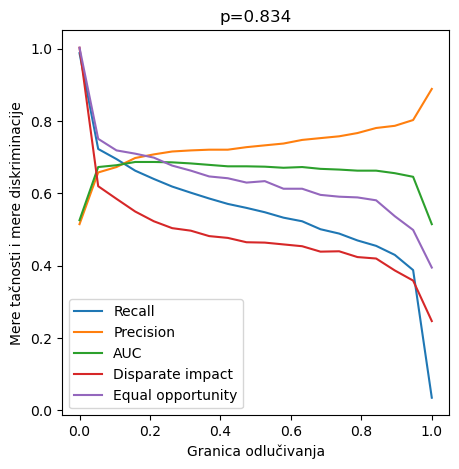

In [48]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.834,:])
plt.plot(Precc.loc[0.834,:])
plt.plot(AUCc.loc[0.834,:])
plt.plot(DIHM.loc[0.834,:])
plt.plot(EQHM.loc[0.834,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.834')
plt.show()

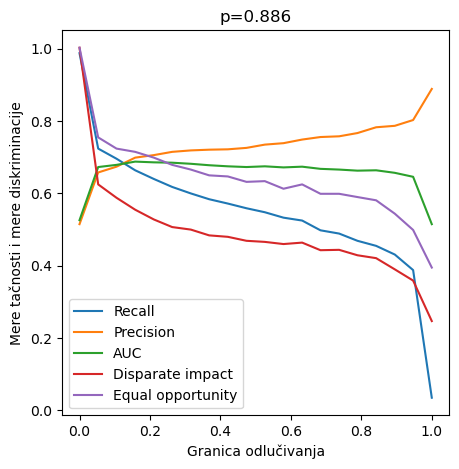

In [49]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.886,:])
plt.plot(Precc.loc[0.886,:])
plt.plot(AUCc.loc[0.886,:])
plt.plot(DIHM.loc[0.886,:])
plt.plot(EQHM.loc[0.886,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.886')
plt.show()

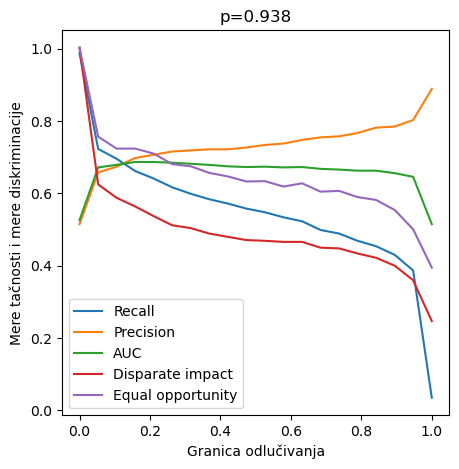

In [50]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.938,:])
plt.plot(Precc.loc[0.938,:])
plt.plot(AUCc.loc[0.938,:])
plt.plot(DIHM.loc[0.938,:])
plt.plot(EQHM.loc[0.938,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.938')
plt.show()

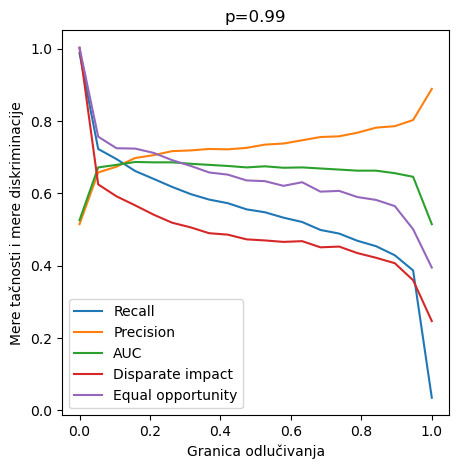

In [51]:
plt.rcParams['figure.figsize']=[5,5]
plt.plot(Recc.loc[0.99,:])
plt.plot(Precc.loc[0.99,:])
plt.plot(AUCc.loc[0.99,:])
plt.plot(DIHM.loc[0.99,:])
plt.plot(EQHM.loc[0.99,:])
plt.legend(['Recall', 'Precision', 'AUC', 'Disparate impact', 'Equal opportunity'])
plt.xlabel("Granica odlučivanja")
plt.ylabel("Mere tačnosti i mere diskriminacije")
plt.title('p=0.99')
plt.show()

Možemo uočiti da, po obe mere, savršenu pravednost postižemo pri granici odlučivanja od 0, odnosno ako bismo sve proglasili za rizične. Kako se granica odlucivanja povecava tako i vrednosti parametra za diskriminaciju opadaju. Medjutim, osim što vrednosti parametara tačnosti (osim recall) nisu zadovoljavajuće, u praksi je jako diskutabilno ukoliko bismo sve prestupnike proglasili za rizične od ponavljanja zločina. S toga, nećemo uzeti u obzir granicu 0, a kako se mere diskriminacije povecavaju sa povecavanjem granica, uzećemo za dalju diskusiju niske vrednosti granice odlučivanja - 0.053, 0.105, 0.158 i 0.211 (iako se autor ovog rada ne slaže sa toliko radikalnim pristupom u donošenju odluka po ovom pitanju)

#### p = 0.834

In [52]:
rez1 = [[Accc.loc[0.834, 0.053], Recc.loc[0.834, 0.053], Precc.loc[0.834, 0.053], F1c.loc[0.834, 0.053], AUCc.loc[0.834, 0.053], DIHM.loc[0.834, 0.053], EQHM.loc[0.834, 0.053]],
        [Accc.loc[0.834, 0.105], Recc.loc[0.834, 0.105], Precc.loc[0.834, 0.105], F1c.loc[0.834, 0.105], AUCc.loc[0.834, 0.105], DIHM.loc[0.834, 0.105], EQHM.loc[0.834, 0.105]],
        [Accc.loc[0.834, 0.158], Recc.loc[0.834, 0.158], Precc.loc[0.834, 0.158], F1c.loc[0.834, 0.158], AUCc.loc[0.834, 0.158], DIHM.loc[0.834, 0.158], EQHM.loc[0.834, 0.158]],
        [Accc.loc[0.834, 0.211], Recc.loc[0.834, 0.211], Precc.loc[0.834, 0.211], F1c.loc[0.834, 0.211], AUCc.loc[0.834, 0.211], DIHM.loc[0.834, 0.211], EQHM.loc[0.834, 0.211]]]

rezultati1 = pd.DataFrame(rez1, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.158, 0.211))
rezultati1

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.673,0.723,0.658,0.689,0.673,0.620,0.751
0.105,0.678,0.695,0.673,0.684,0.678,0.585,0.719
0.158,0.687,0.663,0.698,0.680,0.687,0.550,0.710
0.211,0.687,0.640,0.708,0.672,0.687,0.523,0.699


#### p = 0.886

In [53]:
rez2 = [[Accc.loc[0.886, 0.053], Recc.loc[0.886, 0.053], Precc.loc[0.886, 0.053], F1c.loc[0.886, 0.053], AUCc.loc[0.886, 0.053], DIHM.loc[0.886, 0.053], EQHM.loc[0.886, 0.053]],
        [Accc.loc[0.886, 0.105], Recc.loc[0.886, 0.105], Precc.loc[0.886, 0.105], F1c.loc[0.886, 0.105], AUCc.loc[0.886, 0.105], DIHM.loc[0.886, 0.105], EQHM.loc[0.886, 0.105]],
        [Accc.loc[0.886, 0.158], Recc.loc[0.886, 0.158], Precc.loc[0.886, 0.158], F1c.loc[0.886, 0.158], AUCc.loc[0.886, 0.158], DIHM.loc[0.886, 0.158], EQHM.loc[0.886, 0.158]],
        [Accc.loc[0.886, 0.211], Recc.loc[0.886, 0.211], Precc.loc[0.886, 0.211], F1c.loc[0.886, 0.211], AUCc.loc[0.886, 0.211], DIHM.loc[0.886, 0.211], EQHM.loc[0.886, 0.211]]]

rezultati2 = pd.DataFrame(rez2, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.158, 0.211))
rezultati2

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.673,0.724,0.658,0.690,0.673,0.625,0.755
0.105,0.679,0.696,0.674,0.685,0.679,0.588,0.724
0.158,0.688,0.664,0.699,0.681,0.688,0.555,0.715
0.211,0.686,0.640,0.706,0.672,0.686,0.528,0.699


#### p = 0.938 

In [54]:
rez3 = [[Accc.loc[0.938, 0.053], Recc.loc[0.938, 0.053], Precc.loc[0.938, 0.053], F1c.loc[0.938, 0.053], AUCc.loc[0.938, 0.053], DIHM.loc[0.938, 0.053], EQHM.loc[0.938, 0.053]],
        [Accc.loc[0.938, 0.105], Recc.loc[0.938, 0.105], Precc.loc[0.938, 0.105], F1c.loc[0.938, 0.105], AUCc.loc[0.938, 0.105], DIHM.loc[0.938, 0.105], EQHM.loc[0.938, 0.105]],
        [Accc.loc[0.938, 0.158], Recc.loc[0.938, 0.158], Precc.loc[0.938, 0.158], F1c.loc[0.938, 0.158], AUCc.loc[0.938, 0.158], DIHM.loc[0.938, 0.158], EQHM.loc[0.938, 0.158]],
        [Accc.loc[0.938, 0.211], Recc.loc[0.938, 0.211], Precc.loc[0.938, 0.211], F1c.loc[0.938, 0.211], AUCc.loc[0.938, 0.211], DIHM.loc[0.938, 0.211], EQHM.loc[0.938, 0.211]]]

rezultati3 = pd.DataFrame(rez3, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.158, 0.211))
rezultati3

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.673,0.723,0.658,0.689,0.672,0.625,0.757
0.105,0.679,0.696,0.674,0.685,0.679,0.588,0.724
0.158,0.687,0.662,0.698,0.679,0.687,0.564,0.724
0.211,0.687,0.641,0.707,0.672,0.687,0.537,0.710


#### p = 0.99

In [55]:
rez4 = [[Accc.loc[0.99, 0.053], Recc.loc[0.99, 0.053], Precc.loc[0.99, 0.053], F1c.loc[0.99, 0.053], AUCc.loc[0.99, 0.053], DIHM.loc[0.99, 0.053], EQHM.loc[0.99, 0.053]],
        [Accc.loc[0.99, 0.105], Recc.loc[0.99, 0.105], Precc.loc[0.99, 0.105], F1c.loc[0.99, 0.105], AUCc.loc[0.99, 0.105], DIHM.loc[0.99, 0.105], EQHM.loc[0.99, 0.105]],
        [Accc.loc[0.99, 0.158], Recc.loc[0.99, 0.158], Precc.loc[0.99, 0.158], F1c.loc[0.99, 0.158], AUCc.loc[0.99, 0.158], DIHM.loc[0.99, 0.158], EQHM.loc[0.99, 0.158]],
        [Accc.loc[0.99, 0.211], Recc.loc[0.99, 0.211], Precc.loc[0.99, 0.211], F1c.loc[0.99, 0.211], AUCc.loc[0.99, 0.211], DIHM.loc[0.99, 0.211], EQHM.loc[0.99, 0.211]]]

rezultati4 = pd.DataFrame(rez4, columns=('Accuracy', 'Recall', 'Precision', 'F1', 'AUC', 
                                         'Disparate impact', 'Equal opportunity'), index=(0.053, 0.105, 0.158, 0.211))
rezultati4

,Accuracy,Recall,Precision,F1,AUC,Disparate impact,Equal opportunity
0.053,0.673,0.723,0.658,0.689,0.672,0.625,0.757
0.105,0.679,0.695,0.674,0.684,0.679,0.592,0.725
0.158,0.687,0.662,0.698,0.679,0.687,0.567,0.724
0.211,0.686,0.640,0.706,0.671,0.686,0.541,0.712


Najbolje su se pokazali, po pitanju smanjenja diskriminacije, modeli sa p=0.938 i p=0.99 kod kojih je granica odlučivanja 0.053